# DGPT — Dipan Generative Pre-trained Transformer
### From-scratch decoder-only Transformer (NumPy/CuPy, manual forward + backward + AdamW)

**Target hardware:** Kaggle NVIDIA Tesla T4 (16GB, Turing / SM75)
**Dataset:** TinyStories
**Tokenizer:** locked, pre-trained byte-level BPE (`bpe_6000.json`, vocab=6000), restored from Kaggle Dataset `BPT_V1`. Never retrained here.

**Locked architecture (source of truth: PRD):**

| param | value |
|---|---|
| vocab_size | 6000 |
| block_size | 256 |
| d_model | 384 |
| n_layer | 6 |
| n_head | 6 |
| head_dim | 64 |
| d_ff | 1536 |
| activation | GELU (tanh approx, GPT-2 style) |
| norm | Pre-LN |
| positions | learned |
| lm_head | tied to token embedding |

**"From scratch" means:** Linear, Embedding, LayerNorm, GELU, causal multi-head attention,
residual connections, cross-entropy, the full model forward pass, the full model backward
pass, and AdamW are all hand-implemented in this notebook with manually derived gradients.
No `torch.autograd`, no `loss.backward()`, no `nn.Transformer` / `nn.MultiheadAttention`, no
`torch.optim.AdamW`, no pretrained models, no pretrained tokenizer. CuPy is used strictly as a
**GPU numerical execution backend** (an array library, like NumPy) — it does not provide
autograd and is never used to compute a gradient.

Every layer's backward pass here was independently gradient-checked against finite differences
(max relative error < 1e-5 for isolated layers, < 1e-4 for the full stacked model) before being
placed in this notebook — see Section 20.

**Correct framing for the model card (Section 31):**
> "DGPT implements the Transformer architecture, forward pass, backward pass, and AdamW
> optimization manually, using CuPy as the GPU numerical execution backend."

---

## 01 — Environment / Dependencies

**Cheap. Run once per session.**

In [1]:
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    import tqdm  # noqa
except ImportError:
    pip_install(["tqdm"])

import os, json, time, math, gc, shutil, random
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)

print("Environment ready.")
print("NumPy:", np.__version__)

Environment ready.
NumPy: 2.0.2


## 02 — Backend Selection (NumPy / CuPy)

**Cheap. Run once.**

A clean, explicit `xp` backend object — **no global monkey-patching of `np`**. Every layer
receives `xp` explicitly in its constructor and uses `self.xp` for every op. This replaces the
old notebook's fragile `np = CuPy(...)` monkey-patch design: NumPy and CuPy are never silently
swapped underneath already-constructed objects. Parameters, activations, gradients, temporary
arrays, attention tensors, and optimizer states are all created via the *same* `xp` handed to
the model at construction time, so everything lives on one backend for the whole training step.

In [2]:
USE_GPU = True  # flip to False to force CPU/NumPy reference mode

xp = None
BACKEND_NAME = None

if USE_GPU:
    try:
        import cupy as cp
        _ = cp.zeros(1) + 1  # force init, raises if no CUDA device
        xp = cp
        BACKEND_NAME = "CuPy"
    except Exception as e:
        print(f"CuPy unavailable or GPU init failed ({e}); falling back to NumPy.")
        xp = np
        BACKEND_NAME = "NumPy"
else:
    xp = np
    BACKEND_NAME = "NumPy"

print(f"Selected backend: {BACKEND_NAME}")

Selected backend: CuPy


## 03 — GPU Verification

**Cheap. Run once.** Never claim GPU usage without printing hard evidence.

In [3]:
def gpu_verification_report(xp, backend_name):
    print("=" * 60)
    print("GPU / BACKEND VERIFICATION")
    print("=" * 60)
    print(f"Backend: {backend_name}")

    if backend_name == "CuPy":
        import cupy as cp
        dev = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(dev.id)
        free_b, total_b = cp.cuda.runtime.memGetInfo()
        gpu_name = props['name'].decode() if isinstance(props['name'], bytes) else props['name']
        print(f"CuPy version: {cp.__version__}")
        print(f"GPU: {gpu_name}")
        print(f"Compute capability: {dev.compute_capability}")
        print(f"Total VRAM: {total_b / 1e9:.2f} GB")
        print(f"Free VRAM:  {free_b / 1e9:.2f} GB")

        test = cp.random.randn(4, 4).astype(cp.float32)
        print(f"parameter backend: {type(test)}")
        print(f"dtype: {test.dtype}")
        assert isinstance(test, cp.ndarray), "Backend claims CuPy but array is not cupy.ndarray!"

        if "7.5" not in str(dev.compute_capability) and dev.compute_capability != (7, 5):
            print(f"NOTE: expected SM75 (Turing/T4), detected compute capability {dev.compute_capability}. "
                  f"Some optimization notes in Section 22/23 assume T4 -- re-check them on different hardware.")
    else:
        print("Running on NumPy (CPU reference mode). No GPU claims are being made.")
        test = np.random.randn(4, 4).astype(np.float32)
        print(f"parameter backend: {type(test)}")
        print(f"dtype: {test.dtype}")
    print("=" * 60)

gpu_verification_report(xp, BACKEND_NAME)

GPU / BACKEND VERIFICATION
Backend: CuPy
CuPy version: 14.0.1
GPU: Tesla T4
Compute capability: 75
Total VRAM: 15.64 GB
Free VRAM:  15.52 GB
parameter backend: <class 'cupy.ndarray'>
dtype: float32
NOTE: expected SM75 (Turing/T4), detected compute capability 75. Some optimization notes in Section 22/23 assume T4 -- re-check them on different hardware.


## 04 — Restore Locked BPE Tokenizer from `BPT_V1`

**Cheap. Run once. NEVER retrain BPE — this cell only restores the finished tokenizer.**

256 byte base vocabulary + 5744 learned merges = 6000 final vocabulary. Training already took
~58.8 minutes and is **done**; the tokenizer is a locked external artifact stored as Kaggle
Dataset `dipan04/bpt-v1`.

In [4]:
src = "/kaggle/input/datasets/dipan04/bpt-v1/bpe_6000.json"
dst = "/kaggle/working/data/tokenizer/bpe_6000.json"

os.makedirs(os.path.dirname(dst), exist_ok=True)

if os.path.exists(src):
    shutil.copy2(src, dst)
else:
    alt_src = "/kaggle/input/bpt-v1/bpe_6000.json"  # some Kaggle mounts drop the /datasets/ segment
    if os.path.exists(alt_src):
        shutil.copy2(alt_src, dst)
        src = alt_src
    else:
        raise FileNotFoundError(
            f"Locked tokenizer not found at {src} or {alt_src}. "
            "Attach the BPT_V1 dataset to this notebook before running."
        )

print("Tokenizer restored:", os.path.exists(dst))
print("Source:", src)

Tokenizer restored: True
Source: /kaggle/input/datasets/dipan04/bpt-v1/bpe_6000.json


## 05 — Tokenizer Wrapper (load-only BPE, no training path)

**Cheap.** Standard GPT-2-style byte-level BPE merge loop. This class has **no training
method** — encode/decode only, against the already-learned merge table.

> If `_load` raises a `KeyError` against your actual `bpe_6000.json` schema, run the diagnostic
> cell right after this one, check the printed top-level keys, and adjust `_load` to match —
> this is a pure deserialization fix, never a retrain.

In [10]:
import json

with open(dst, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())
print("Number of merges:", len(data["merge_order"]))
print("First merge entry:", repr(data["merge_order"][0]))
print("Second merge entry:", repr(data["merge_order"][1]))

Top-level keys: dict_keys(['vocab_size', 'merge_order'])
Number of merges: 5744
First merge entry: [[101, 32], 256]
Second merge entry: [[100, 32], 257]


In [12]:
class BPETokenizer:
    """
    Loads an ALREADY-TRAINED byte-level BPE tokenizer.

    BPT_V1 actual schema:
        {
            "vocab_size": 6000,
            "merge_order": [
                [[a_id, b_id], new_id],
                ...
            ]
        }

    Example:
        [[101, 32], 256]
        [[100, 32], 257]

    No tokenizer training is performed here.
    """

    def __init__(self, path):
        self.path = path
        self.schema = None
        self._load(path)

    def _load(self, path):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        self._raw_top_level_keys = list(data.keys())

        # ----------------------------------------------------
        # Schema B: HuggingFace tokenizers.json
        # ----------------------------------------------------
        if (
            "model" in data
            and isinstance(data["model"], dict)
            and "vocab" in data["model"]
        ):
            self.schema = "B_hf_tokenizers_json"
            self._load_schema_b(data["model"])

        # ----------------------------------------------------
        # Schema C: GPT-2 / split vocab+merges
        # ----------------------------------------------------
        elif (
            "vocab" in data
            and "merges" in data
            and isinstance(data["vocab"], dict)
            and len(data["vocab"]) > 0
            and all(
                isinstance(v, int)
                for v in list(data["vocab"].values())[:3]
            )
        ):
            self.schema = "C_gpt2_split"
            self._load_schema_c(data)

        # ----------------------------------------------------
        # Schema A: flat custom vocab + merges
        # ----------------------------------------------------
        elif (
            "vocab" in data
            and "merges" in data
        ):
            self.schema = "A_flat_custom"
            self._load_schema_a(data)

        # ----------------------------------------------------
        # Schema D: ACTUAL BPT_V1 format
        # ----------------------------------------------------
        elif (
            "merge_order" in data
            and "vocab" not in data
        ):
            self.schema = "D_bpt_v1"
            self._load_schema_d(data)

        else:
            raise KeyError(
                "Could not detect tokenizer schema. "
                f"Top-level keys found: "
                f"{self._raw_top_level_keys}. "
                "DO NOT regenerate the tokenizer."
            )

        self.vocab_size = (
            getattr(self, "vocab_size", None)
            or len(self.id_to_bytes)
        )

        print(
            f"BPETokenizer: detected schema "
            f"'{self.schema}', "
            f"vocab_size={self.vocab_size}"
        )

    # ========================================================
    # Schema A
    # ========================================================

    def _load_schema_a(self, data):
        self.vocab_size = data.get(
            "vocab_size",
            len(data.get("vocab", {}))
        )

        merges_list = data["merges"]

        self.bpe_ranks = {
            tuple(pair): i
            for i, pair in enumerate(merges_list)
        }

        vocab = data["vocab"]

        self.id_to_bytes = {
            int(k): tuple(v)
            for k, v in vocab.items()
        }

        self.bytes_to_id = {
            v: k
            for k, v in self.id_to_bytes.items()
        }

    # ========================================================
    # Schema B
    # ========================================================

    def _load_schema_b(self, model):
        self._build_from_str_vocab_and_merges(
            model["vocab"],
            model["merges"]
        )

    # ========================================================
    # Schema C
    # ========================================================

    def _load_schema_c(self, data):
        self._build_from_str_vocab_and_merges(
            data["vocab"],
            data["merges"]
        )

    # ========================================================
    # Schema D — ACTUAL BPT_V1
    # ========================================================

    def _load_schema_d(self, data):
        """
        Actual BPT_V1 representation:

            merge_order = [
                [[a_id, b_id], new_id],
                ...
            ]

        Example:

            [[101, 32], 256]
            [[100, 32], 257]
        """

        merge_order = data["merge_order"]

        # ----------------------------------------------------
        # Base vocabulary: raw bytes 0..255
        # ----------------------------------------------------
        self.id_to_bytes = {
            i: (i,)
            for i in range(256)
        }

        self.bpe_ranks = {}

        # ----------------------------------------------------
        # Learned merges
        # ----------------------------------------------------
        for rank, entry in enumerate(merge_order):

            a_id, b_id, new_id = (
                self._normalize_merge_entry(entry)
            )

            # Merge priority = position in merge_order
            self.bpe_ranks[
                (a_id, b_id)
            ] = rank

            # Store the exact resulting token ID
            self.id_to_bytes[
                new_id
            ] = (a_id, b_id)

        # ----------------------------------------------------
        # Reverse lookup
        # ----------------------------------------------------
        self.bytes_to_id = {
            v: k
            for k, v in self.id_to_bytes.items()
        }

        # ----------------------------------------------------
        # Validate vocabulary size
        # ----------------------------------------------------
        declared_vocab_size = data.get(
            "vocab_size"
        )

        computed_vocab_size = (
            max(self.id_to_bytes.keys()) + 1
        )

        if (
            declared_vocab_size is not None
            and declared_vocab_size
            != computed_vocab_size
        ):
            raise ValueError(
                f"BPT_V1 tokenizer mismatch: "
                f"declared vocab_size="
                f"{declared_vocab_size}, "
                f"computed="
                f"{computed_vocab_size}. "
                "The tokenizer artifact is locked; "
                "do NOT regenerate it."
            )

        self.vocab_size = computed_vocab_size

    # ========================================================
    # Merge-entry normalization
    # ========================================================

    @staticmethod
    def _normalize_merge_entry(entry):
        """
        Actual BPT_V1 format:

            [[a_id, b_id], new_id]

        Returns:
            a_id, b_id, new_id
        """

        if (
            isinstance(entry, (list, tuple))
            and len(entry) == 2
            and isinstance(
                entry[0],
                (list, tuple)
            )
            and len(entry[0]) == 2
        ):
            a_id = int(entry[0][0])
            b_id = int(entry[0][1])
            new_id = int(entry[1])

            return (
                a_id,
                b_id,
                new_id
            )

        # Defensive support for wrapped dictionary forms.
        if isinstance(entry, dict):

            for key in (
                "pair",
                "ids",
                "merge"
            ):

                if key not in entry:
                    continue

                pair = entry[key]

                if (
                    isinstance(
                        pair,
                        (list, tuple)
                    )
                    and len(pair) == 2
                ):

                    new_id = entry.get(
                        "new_id",
                        entry.get("id")
                    )

                    if new_id is None:
                        raise KeyError(
                            "Merge entry has no "
                            f"new token ID: {entry!r}"
                        )

                    return (
                        int(pair[0]),
                        int(pair[1]),
                        int(new_id)
                    )

        raise KeyError(
            "Unrecognized BPT_V1 merge entry: "
            f"{entry!r}"
        )

    # ========================================================
    # String-vocab schemas
    # ========================================================

    def _build_from_str_vocab_and_merges(
        self,
        str_vocab,
        merges_raw
    ):
        """
        Supports standard vocab-string / merge-string schemas.
        """

        id_to_str = {
            v: k
            for k, v in str_vocab.items()
        }

        base_ids = sorted(
            i
            for i in id_to_str
            if i < 256
        )

        self.id_to_bytes = {}

        for i in base_ids:
            self.id_to_bytes[i] = (i,)

        resolved_pairs = []

        # ----------------------------------------------------
        # String merge form:
        # ["a b", "c d", ...]
        # ----------------------------------------------------
        if (
            merges_raw
            and isinstance(
                merges_raw[0],
                str
            )
        ):

            for m in merges_raw:

                a_str, b_str = (
                    m.split(" ", 1)
                )

                a_id = str_vocab.get(
                    a_str
                )

                b_id = str_vocab.get(
                    b_str
                )

                merged_str = (
                    a_str + b_str
                )

                merged_id = str_vocab.get(
                    merged_str
                )

                if (
                    a_id is None
                    or b_id is None
                    or merged_id is None
                ):
                    continue

                resolved_pairs.append(
                    (
                        a_id,
                        b_id,
                        merged_id
                    )
                )

        # ----------------------------------------------------
        # Numeric merge form:
        # [[a,b], ...]
        # ----------------------------------------------------
        else:

            for pair in merges_raw:

                if (
                    not isinstance(
                        pair,
                        (list, tuple)
                    )
                    or len(pair) != 2
                ):
                    continue

                a_id = int(pair[0])
                b_id = int(pair[1])

                merged_string = (
                    id_to_str.get(a_id, "")
                    + id_to_str.get(b_id, "")
                )

                merged_id = str_vocab.get(
                    merged_string
                )

                if merged_id is None:
                    continue

                resolved_pairs.append(
                    (
                        a_id,
                        b_id,
                        merged_id
                    )
                )

        self.bpe_ranks = {}

        for rank, (
            a_id,
            b_id,
            merged_id
        ) in enumerate(
            resolved_pairs
        ):

            self.bpe_ranks[
                (a_id, b_id)
            ] = rank

            self.id_to_bytes[
                merged_id
            ] = (
                a_id,
                b_id
            )

        self.bytes_to_id = {
            v: k
            for k, v in self.id_to_bytes.items()
        }

        self.vocab_size = len(
            str_vocab
        )

    # ========================================================
    # BPE helpers
    # ========================================================

    def _get_pairs(self, seq):
        return set(
            zip(
                seq[:-1],
                seq[1:]
            )
        )

    def _bpe_merge(self, seq):

        seq = list(seq)

        if len(seq) < 2:
            return seq

        while True:

            pairs = self._get_pairs(seq)

            if not pairs:
                break

            ranked = [
                (
                    self.bpe_ranks[p],
                    p
                )
                for p in pairs
                if p in self.bpe_ranks
            ]

            if not ranked:
                break

            _, best = min(ranked)

            new_seq = []
            i = 0

            while i < len(seq):

                if (
                    i < len(seq) - 1
                    and (
                        seq[i],
                        seq[i + 1]
                    ) == best
                ):

                    merged_id = (
                        self.bytes_to_id.get(
                            (
                                seq[i],
                                seq[i + 1]
                            )
                        )
                    )

                    if merged_id is None:
                        raise RuntimeError(
                            "Missing merged token ID "
                            f"for pair {best}"
                        )

                    new_seq.append(
                        merged_id
                    )

                    i += 2

                else:

                    new_seq.append(
                        seq[i]
                    )

                    i += 1

            seq = new_seq

        return seq

    # ========================================================
    # Encode
    # ========================================================

    def encode(self, text):

        raw_bytes = text.encode(
            "utf-8"
        )

        return self._bpe_merge(
            list(raw_bytes)
        )

    # ========================================================
    # Decode
    # ========================================================

    def decode(self, ids):

        out = bytearray()

        for token_id in ids:

            token_id = int(
                token_id
            )

            if token_id < 256:

                out.append(
                    token_id
                )

            elif token_id in self.id_to_bytes:

                out.extend(
                    self._expand(
                        token_id
                    )
                )

            else:
                raise KeyError(
                    f"Unknown token ID: "
                    f"{token_id}"
                )

        return bytes(
            out
        ).decode(
            "utf-8",
            errors="replace"
        )

    # ========================================================
    # Recursive token expansion
    # ========================================================

    def _expand(self, token_id):

        if token_id < 256:
            return bytes([token_id])

        if token_id not in self.id_to_bytes:
            raise KeyError(
                f"Unknown token ID during "
                f"decode: {token_id}"
            )

        out = bytearray()

        for part in self.id_to_bytes[
            token_id
        ]:

            if part >= 256:
                out.extend(
                    self._expand(part)
                )

            else:
                out.append(part)

        return bytes(
            out
        )


# ============================================================
# Load and validate the locked BPT_V1 tokenizer
# ============================================================

tokenizer = BPETokenizer(dst)

print(
    "Tokenizer schema:",
    tokenizer.schema
)

print(
    "Tokenizer vocab:",
    tokenizer.vocab_size
)

assert (
    tokenizer.vocab_size == 6000
), (
    f"Expected vocab_size=6000, "
    f"got {tokenizer.vocab_size}"
)

# Round-trip validation
sample_text = (
    "Once upon a time, there was "
    "a little dog."
)

sample_ids = tokenizer.encode(
    sample_text
)

sample_decoded = tokenizer.decode(
    sample_ids
)

print(
    "Sample token count:",
    len(sample_ids)
)

print(
    "Decoded sample:",
    sample_decoded
)

assert (
    sample_decoded == sample_text
), "Tokenizer round-trip FAILED"

print(
    "\nBPT_V1 TOKENIZER VALIDATION: PASS"
)

BPETokenizer: detected schema 'D_bpt_v1', vocab_size=6000
Tokenizer schema: D_bpt_v1
Tokenizer vocab: 6000
Sample token count: 2
Decoded sample: Once upon a time, there was a little dog.

BPT_V1 TOKENIZER VALIDATION: PASS


In [13]:
tokenizer = BPETokenizer(dst)

print("schema:", tokenizer.schema)
print("vocab:", tokenizer.vocab_size)

sample = "Once upon a time, there was a little dog."

ids = tokenizer.encode(sample)
decoded = tokenizer.decode(ids)

print("tokens:", ids[:30])
print("decoded:", decoded)

assert tokenizer.vocab_size == 6000
assert decoded == sample

print("Tokenizer test: PASS")

BPETokenizer: detected schema 'D_bpt_v1', vocab_size=6000
schema: D_bpt_v1
vocab: 6000
tokens: [1631, 4704]
decoded: Once upon a time, there was a little dog.
Tokenizer test: PASS


In [14]:
# ============================================================
# Tokenizer compatibility test (Fix #1) -- run every session.
# Confirms the locked BPT_V1 artifact loads correctly under whatever schema it actually
# uses, WITHOUT retraining or regenerating anything.
# ============================================================
_compat_report = {"file_exists": os.path.exists(dst)}

assert _compat_report["file_exists"], "Tokenizer file missing -- rerun Section 04, do NOT retrain."

_compat_report["vocab_size"] = tokenizer.vocab_size
_compat_report["vocab_size_ok"] = (tokenizer.vocab_size == 6000)

_test_str = "Once upon a time, there was a little dog."
_enc = tokenizer.encode(_test_str)
_compat_report["encode_ok"] = isinstance(_enc, list) and len(_enc) > 0

_dec = tokenizer.decode(_enc)
_compat_report["decode_ok"] = isinstance(_dec, str) and len(_dec) > 0

_compat_report["roundtrip_ok"] = (_dec.strip() == _test_str.strip())

print("=" * 60)
print(f"Tokenizer source: BPT_V1 ({tokenizer.schema})")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"File exists: {'PASS' if _compat_report['file_exists'] else 'FAIL'}")
print(f"Vocab size == 6000: {'PASS' if _compat_report['vocab_size_ok'] else 'FAIL'}")
print(f"Encode: {'PASS' if _compat_report['encode_ok'] else 'FAIL'}")
print(f"Decode: {'PASS' if _compat_report['decode_ok'] else 'FAIL'}")
print(f"Round-trip: {'PASS' if _compat_report['roundtrip_ok'] else 'FAIL'}")
print("BPE retraining: NOT REQUIRED")
print("=" * 60)

assert _compat_report["vocab_size_ok"], (
    f"Loaded vocab_size={tokenizer.vocab_size}, expected 6000. The tokenizer artifact itself "
    f"is the source of truth -- if this fails, the LOADER has a bug, the artifact does not. "
    f"Do not regenerate merges to force 6000."
)
assert _compat_report["encode_ok"] and _compat_report["decode_ok"] and _compat_report["roundtrip_ok"], (
    "Tokenizer compatibility test failed -- fix BPETokenizer._load for the actual on-disk "
    "schema (see printed top-level keys above / schema detection message), do not retrain."
)

print("\nTop-level keys in bpe_6000.json:", tokenizer._raw_top_level_keys)

Tokenizer source: BPT_V1 (D_bpt_v1)
Vocabulary size: 6000
File exists: PASS
Vocab size == 6000: PASS
Encode: PASS
Decode: PASS
Round-trip: PASS
BPE retraining: NOT REQUIRED

Top-level keys in bpe_6000.json: ['vocab_size', 'merge_order']


## 06 — Load / Prepare TinyStories

**Kaggle-only** (needs the TinyStories dataset attached, e.g. `roneneldan/tinystories`). Long
first run (reads + concatenates raw text), cheap on reruns.

In [17]:
!git clone https://huggingface.co/datasets/roneneldan/TinyStories

Cloning into 'TinyStories'...
remote: Enumerating objects: 69, done.
remote: Total 69 (delta 0), reused 0 (delta 0), pack-reused 69 (from 1)
Receiving objects: 100% (69/69), 14.53 KiB | 3.63 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Filtering content: 100% (11/11), 7.09 GiB | 17.80 MiB/s, done.


In [20]:
TINYSTORIES_CANDIDATES = [
    "/kaggle/working/tinystories/TinyStoriesV2-GPT4-train.txt",
    "/kaggle/working/tinystories/TinyStories-train.txt",
    "/kaggle/working/tinystories-narrative-classification/tinystories-train.csv",
]

tinystories_path = None
for p in TINYSTORIES_CANDIDATES:
    if os.path.exists(p):
        tinystories_path = p
        break

if tinystories_path is None:
    # last resort: scan /kaggle/input for anything with tinystor* in the name
    for root, _, files in os.walk("/kaggle/working"):
        for fn in files:
            if "tinystor" in fn.lower() and (fn.endswith(".txt") or fn.endswith(".csv")):
                tinystories_path = os.path.join(root, fn)
                break
        if tinystories_path:
            break

if tinystories_path is None:
    raise FileNotFoundError(
        "TinyStories dataset not found under /kaggle/input. Attach a TinyStories dataset "
        "to this notebook (e.g. roneneldan/tinystories) and re-run."
    )

print("Using TinyStories source:", tinystories_path)

def load_stories(path, max_chars=None):
    stories = []
    if path.endswith(".csv"):
        import csv
        with open(path, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            text_col = "text" if "text" in reader.fieldnames else reader.fieldnames[0]
            for row in reader:
                stories.append(row[text_col])
                if max_chars and sum(len(s) for s in stories) > max_chars:
                    break
    else:
        with open(path, "r", encoding="utf-8") as f:
            raw = f.read()
        # TinyStories GPT4 format separates stories with "<|endoftext|>"
        stories = [s.strip() for s in raw.split("<|endoftext|>") if s.strip()]
        if max_chars:
            total, kept = 0, []
            for s in stories:
                kept.append(s)
                total += len(s)
                if total > max_chars:
                    break
            stories = kept
    return stories

all_stories = load_stories(tinystories_path)
print(f"Total stories loaded: {len(all_stories):,}")
print("Sample story:\n", all_stories[0][:300])

Using TinyStories source: /kaggle/working/TinyStories/TinyStoriesV2-GPT4-train.txt
Total stories loaded: 2,717,495
Sample story:
 Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said


In [21]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/dipan04/bpt-v1/bpe_6000.json


## 07 — Tokenized Dataset Representation

**Long the first time** (tokenizes every story once), **cheap afterward** if cached to disk.
Tokenization happens **once** here -- training steps only slice pre-tokenized integer arrays,
never call `tokenizer.encode()` per-step.

In [22]:
TOKEN_CACHE_PATH = "/kaggle/working/data/tokenized/tinystories_tokens.npy"
STAGE2_SUBSET_SIZE = 50_000   # rapid-iteration subset, per PRD Stage 2

os.makedirs(os.path.dirname(TOKEN_CACHE_PATH), exist_ok=True)

def build_token_array(stories, tokenizer, cache_path, eos_id=None):
    if os.path.exists(cache_path):
        print(f"Loading cached tokenized dataset from {cache_path}")
        return np.load(cache_path)

    if eos_id is None:
        eos_id = 256  # first merged-token id above the raw byte range acts as a soft doc separator
                       # (falls back gracefully -- decode() only special-cases ids < 256)

    all_ids = []
    for story in tqdm(stories, desc="Tokenizing (one-time)"):
        ids = tokenizer.encode(story)
        all_ids.extend(ids)
        all_ids.append(eos_id)

    arr = np.array(all_ids, dtype=np.int32)
    np.save(cache_path, arr)
    print(f"Tokenized dataset cached to {cache_path} ({arr.shape[0]:,} tokens)")
    return arr

# Stage 2 rapid-iteration subset (50k stories per PRD)
stage2_stories = all_stories[:STAGE2_SUBSET_SIZE]
stage2_tokens = build_token_array(
    stage2_stories, tokenizer,
    cache_path="/kaggle/working/data/tokenized/stage2_tokens.npy",
)

n_val = max(1, int(0.02 * len(stage2_tokens)))
stage2_train_tokens = stage2_tokens[:-n_val]
stage2_val_tokens = stage2_tokens[-n_val:]

print(f"Stage 2 tokens: train={len(stage2_train_tokens):,}  val={len(stage2_val_tokens):,}")

Tokenizing (one-time):   0%|          | 0/50000 [00:00<?, ?it/s]

Tokenized dataset cached to /kaggle/working/data/tokenized/stage2_tokens.npy (6,887,068 tokens)
Stage 2 tokens: train=6,749,327  val=137,741


## 07b — GPU-Resident Stage 2 Data (Fix #2)

**Cheap (one-time transfer).** `get_batch()` previously kept the Stage-2 token array on host
RAM and copied a fresh batch CPU->GPU on every single training step. For the 50k-story subset
that's wasteful: the whole tokenized array easily fits in T4's 16GB alongside a ~13M-param
model, so we tokenize once (already done in Section 07), transfer the integer token array to
the GPU **once**, and from then on draw random batch windows with GPU-side fancy indexing --
no further host<->device traffic for Stage-2 batches.

If the array does *not* safely fit (checked against actual free VRAM with a safety margin),
this falls back to `DATASET_RESIDENCY = "cpu"` and batches are transferred per-step as before --
never silently place something too large on GPU.

In [23]:
def report_gpu_mem(prefix=""):
    if BACKEND_NAME == "CuPy":
        free_b, total_b = xp.cuda.runtime.memGetInfo()
        pool = xp.get_default_memory_pool()
        print(f"{prefix}free={free_b/1e9:.3f} GB | used={((total_b-free_b)/1e9):.3f} GB | "
              f"cupy_pool_used={pool.used_bytes()/1e9:.3f} GB | cupy_pool_total={pool.total_bytes()/1e9:.3f} GB")
    else:
        print(f"{prefix}(NumPy backend -- host RAM, not tracked here)")

def determine_and_apply_residency(token_array_np, xp, backend_name, safety_factor=4):
    """
    Uploads token_array_np to the GPU ONCE if it safely fits (needed_bytes * safety_factor <
    free_bytes, leaving headroom for model/activations/optimizer state). Returns
    (residency, array) where array is either the original NumPy array (residency='cpu') or an
    xp array already resident on the backend device (residency='gpu').
    """
    size_mb = token_array_np.nbytes / 1e6
    print(f"Stage 2 token array size: {size_mb:.2f} MB ({len(token_array_np):,} tokens, int32)")

    if backend_name != "CuPy":
        print("Backend is NumPy -- DATASET_RESIDENCY = 'cpu' (no GPU to place data on).")
        return "cpu", token_array_np

    free_before, total_b = xp.cuda.runtime.memGetInfo()
    print(f"GPU memory before upload: free={free_before/1e9:.3f} GB / total={total_b/1e9:.3f} GB")

    needed = token_array_np.nbytes
    if needed * safety_factor < free_before:
        gpu_arr = xp.asarray(token_array_np.astype(np.int32))
        free_after, _ = xp.cuda.runtime.memGetInfo()
        print(f"GPU memory after upload:  free={free_after/1e9:.3f} GB")
        print(f"GPU memory available for model/training: ~{free_after/1e9:.3f} GB")
        print("DATASET_RESIDENCY = 'gpu'")
        return "gpu", gpu_arr
    else:
        print(f"Dataset ({needed/1e9:.3f} GB) too large relative to free VRAM "
              f"({free_before/1e9:.3f} GB, safety_factor={safety_factor}x) to safely reside on "
              f"GPU alongside the model. Falling back to DATASET_RESIDENCY = 'cpu'.")
        return "cpu", token_array_np


DATASET_RESIDENCY, stage2_train_tokens_dev = determine_and_apply_residency(
    stage2_train_tokens, xp, BACKEND_NAME)

# validation set is tiny -- always safe to co-locate at the same residency for consistent code paths
if DATASET_RESIDENCY == "gpu":
    stage2_val_tokens_dev = xp.asarray(stage2_val_tokens.astype(np.int32))
else:
    stage2_val_tokens_dev = stage2_val_tokens

print(f"\nDATASET_RESIDENCY = '{DATASET_RESIDENCY}'")

Stage 2 token array size: 27.00 MB (6,749,327 tokens, int32)
GPU memory before upload: free=15.522 GB / total=15.636 GB
GPU memory after upload:  free=15.495 GB
GPU memory available for model/training: ~15.495 GB
DATASET_RESIDENCY = 'gpu'

DATASET_RESIDENCY = 'gpu'


## 08 — Batch Sampler (contiguous integer arrays, direct-to-GPU batches)

**Cheap.**

In [25]:
def get_batch(token_array, batch_size, block_size, xp, residency="cpu", rng=None):
    """
    residency='cpu': token_array is a host NumPy array; a batch is gathered on host then
        copied to the backend device (xp.asarray) -- one CPU->GPU transfer PER BATCH.
    residency='gpu': token_array is already an xp array resident on the training device.
        Start indices AND the gather itself happen entirely on-device via fancy indexing --
        no per-batch host<->device transfer at all.
    """
    n = token_array.shape[0] if residency == "gpu" else len(token_array)
    max_start = n - block_size - 1

    if residency == "gpu":
        starts = xp.random.randint(0, max_start, size=batch_size)
        offsets = xp.arange(block_size)
        idx_x = starts[:, None] + offsets[None, :]          # (B, T) gather indices, on-device
        idx_y = idx_x + 1
        x = token_array[idx_x].astype(xp.int64)
        y = token_array[idx_y].astype(xp.int64)
        return x, y

    if rng is None:
        rng = np.random
    starts = rng.randint(0, max_start, size=batch_size)
    x_np = np.stack([token_array[s:s + block_size] for s in starts]).astype(np.int64)
    y_np = np.stack([token_array[s + 1:s + 1 + block_size] for s in starts]).astype(np.int64)
    x = xp.asarray(x_np)
    y = xp.asarray(y_np)
    return x, y

# smoke test -- exercises whichever residency Section 07b actually selected
_xb, _yb = get_batch(stage2_train_tokens_dev, batch_size=4, block_size=32, xp=xp,
                      residency=DATASET_RESIDENCY)
print("batch x shape:", _xb.shape, "dtype:", _xb.dtype, "| residency:", DATASET_RESIDENCY)
print("batch y shape:", _yb.shape, "dtype:", _yb.dtype)

batch x shape: (4, 32) dtype: int64 | residency: gpu
batch y shape: (4, 32) dtype: int64


## 09 — Core Tensor Utilities

**Cheap.** Stable softmax used by both attention and cross-entropy. Numerically stable
(subtracts row-max before `exp`), backend-agnostic.

In [27]:
def stable_softmax(x, xp, axis=-1):
    x_max = xp.max(x, axis=axis, keepdims=True)
    e = xp.exp(x - x_max)
    s = e / xp.sum(e, axis=axis, keepdims=True)
    return s

## 10 — Linear Layer (manual forward + backward)

**Cheap.** `y = xW + b`. Backward: `dW = x^T dy`, `db = sum(dy)`, `dx = dy W^T`.

In [29]:
class Linear:
    def __init__(self, in_features, out_features, xp, bias=True, name="linear"):
        self.xp = xp
        self.name = name
        self.bias_enabled = bias
        scale = (1.0 / in_features) ** 0.5
        self.W = xp.random.uniform(-scale, scale, size=(in_features, out_features)).astype(xp.float32)
        self.b = xp.zeros((out_features,), dtype=xp.float32) if bias else None
        self.x_cache = None

    def params(self):
        p = {"W": self.W}
        if self.bias_enabled:
            p["b"] = self.b
        return p

    def forward(self, x):
        self.x_cache = x
        out = x @ self.W
        if self.bias_enabled:
            out = out + self.b
        return out

    def backward(self, dout):
        x = self.x_cache
        orig_shape = x.shape
        x2 = x.reshape(-1, orig_shape[-1])
        dout2 = dout.reshape(-1, dout.shape[-1])

        dW = x2.T @ dout2
        db = dout2.sum(axis=0) if self.bias_enabled else None
        dx = (dout2 @ self.W.T).reshape(orig_shape)

        grads = {"W": dW}
        if self.bias_enabled:
            grads["b"] = db
        return dx, grads

## 11 — Embedding (token + learned positional, scatter-add backward)

**Cheap.** Token embedding backward uses scatter-add (`xp.add.at`) since the same row of `W`
can be looked up by multiple positions in a batch — gradients must accumulate, not overwrite.

In [30]:
class Embedding:
    def __init__(self, vocab_size, d_model, xp, name="embedding"):
        self.xp = xp
        self.name = name
        scale = (1.0 / d_model) ** 0.5
        self.W = xp.random.uniform(-scale, scale, size=(vocab_size, d_model)).astype(xp.float32)
        self.idx_cache = None
        self.vocab_size = vocab_size

    def params(self):
        return {"W": self.W}

    def forward(self, idx):
        self.idx_cache = idx
        return self.W[idx]

    def backward(self, dout):
        xp = self.xp
        idx = self.idx_cache
        dW = xp.zeros_like(self.W)
        flat_idx = idx.reshape(-1)
        flat_dout = dout.reshape(-1, dout.shape[-1])
        xp.add.at(dW, flat_idx, flat_dout)
        return None, {"W": dW}


class PositionalEmbedding:
    '''Learned positional embedding, per PRD (not sinusoidal).'''
    def __init__(self, block_size, d_model, xp, name="pos_embedding"):
        self.xp = xp
        self.name = name
        scale = (1.0 / d_model) ** 0.5
        self.W = xp.random.uniform(-scale, scale, size=(block_size, d_model)).astype(xp.float32)
        self.T_cache = None

    def params(self):
        return {"W": self.W}

    def forward(self, T):
        self.T_cache = T
        return self.W[:T]

    def backward(self, dout):
        xp = self.xp
        T = self.T_cache
        dW = xp.zeros_like(self.W)
        dW[:T] = dout.sum(axis=0)
        return None, {"W": dW}

## 12 — LayerNorm (manual forward + backward)

**Cheap.** Standard LayerNorm backward over the last axis:
`dx = (1/N) * std_inv * (N*dx_hat - sum(dx_hat) - x_hat*sum(dx_hat*x_hat))`.

In [32]:
class LayerNorm:
    def __init__(self, d_model, xp, eps=1e-5, name="ln"):
        self.xp = xp
        self.name = name
        self.eps = eps
        self.gamma = xp.ones((d_model,), dtype=xp.float32)
        self.beta = xp.zeros((d_model,), dtype=xp.float32)
        self.cache = None

    def params(self):
        return {"gamma": self.gamma, "beta": self.beta}

    def forward(self, x):
        xp = self.xp
        mu = x.mean(axis=-1, keepdims=True)
        var = x.var(axis=-1, keepdims=True)
        std_inv = 1.0 / xp.sqrt(var + self.eps)
        x_hat = (x - mu) * std_inv
        out = self.gamma * x_hat + self.beta
        self.cache = (x_hat, std_inv)
        return out

    def backward(self, dout):
        xp = self.xp
        x_hat, std_inv = self.cache
        N = dout.shape[-1]

        dgamma = (dout * x_hat).reshape(-1, N).sum(axis=0)
        dbeta = dout.reshape(-1, N).sum(axis=0)

        dx_hat = dout * self.gamma
        sum_dxhat = dx_hat.sum(axis=-1, keepdims=True)
        sum_dxhat_xhat = (dx_hat * x_hat).sum(axis=-1, keepdims=True)
        dx = (1.0 / N) * std_inv * (N * dx_hat - sum_dxhat - x_hat * sum_dxhat_xhat)
        return dx, {"gamma": dgamma, "beta": dbeta}

## 13 — GELU (manual forward + backward)

**Cheap.** GPT-2's tanh approximation of GELU:
`0.5x(1 + tanh(sqrt(2/pi)(x + 0.044715x^3)))`, with hand-derived backward.

In [33]:
class GELU:
    def __init__(self, xp, name="gelu"):
        self.xp = xp
        self.name = name
        self.cache = None

    def params(self):
        return {}

    def forward(self, x):
        xp = self.xp
        c = xp.float32((2.0 / xp.pi) ** 0.5)
        inner = c * (x + 0.044715 * x ** 3)
        tanh_inner = xp.tanh(inner)
        out = 0.5 * x * (1.0 + tanh_inner)
        self.cache = (x, tanh_inner, c)
        return out

    def backward(self, dout):
        xp = self.xp
        x, tanh_inner, c = self.cache
        sech2 = 1.0 - tanh_inner ** 2
        d_inner_dx = c * (1.0 + 3 * 0.044715 * x ** 2)
        dgelu_dx = 0.5 * (1.0 + tanh_inner) + 0.5 * x * sech2 * d_inner_dx
        dx = dout * dgelu_dx
        return dx, {}

## 14 — Single-Head Attention Derivation (reference, unvectorized)

**Cheap.** A slow, explicit single-head reference implementation used only to sanity-check
the vectorized multi-head version in Section 15 (see gradient/shape checks in Section 20).
Not used in the training path.

In [34]:
def single_head_attention_reference(x, Wq, Wk, Wv, xp):
    '''x: (T, C). Returns (out, A) for ONE head, ONE sequence -- reference only.'''
    T, C = x.shape
    Q = x @ Wq
    K = x @ Wk
    V = x @ Wv
    scale = 1.0 / (Q.shape[-1] ** 0.5)
    scores = (Q @ K.T) * scale
    mask = xp.triu(xp.ones((T, T), dtype=xp.bool_), k=1)
    scores = xp.where(mask, xp.float32(-1e9), scores)
    A = stable_softmax(scores, xp, axis=-1)
    out = A @ V
    return out, A

## 15 — Multi-Head Causal Attention (manual forward + backward)

**Cheap.** Fully vectorized `(B, H, T, hd)` batched attention. Backward explicitly implements
`dV`, `dA` (softmax backward), `dS` (scaled scores), `dQ`, `dK`, and routes gradients through
the Q/K/V/O projections. No autograd.

In [35]:
class CausalSelfAttention:
    def __init__(self, d_model, n_head, block_size, xp, name="attn"):
        assert d_model % n_head == 0
        self.xp = xp
        self.name = name
        self.d_model = d_model
        self.n_head = n_head
        self.head_dim = d_model // n_head
        self.block_size = block_size

        self.Wq = Linear(d_model, d_model, xp, bias=True, name="Wq")
        self.Wk = Linear(d_model, d_model, xp, bias=True, name="Wk")
        self.Wv = Linear(d_model, d_model, xp, bias=True, name="Wv")
        self.Wo = Linear(d_model, d_model, xp, bias=True, name="Wo")

        self._mask_cache = {}   # reused across calls -- never reallocated per step
        self.cache = None

    def params(self):
        p = {}
        for sub in ("Wq", "Wk", "Wv", "Wo"):
            layer = getattr(self, sub)
            for k, v in layer.params().items():
                p[f"{sub}.{k}"] = v
        return p

    def _get_mask(self, T):
        xp = self.xp
        if T not in self._mask_cache:
            self._mask_cache[T] = xp.triu(xp.ones((T, T), dtype=xp.bool_), k=1)
        return self._mask_cache[T]

    def forward(self, x):
        xp = self.xp
        B, T, C = x.shape
        H, hd = self.n_head, self.head_dim

        Q = self.Wq.forward(x)
        K = self.Wk.forward(x)
        V = self.Wv.forward(x)

        def split_heads(t):
            return t.reshape(B, T, H, hd).transpose(0, 2, 1, 3)

        Qh, Kh, Vh = split_heads(Q), split_heads(K), split_heads(V)

        scale = xp.float32(1.0 / (hd ** 0.5))
        scores = xp.matmul(Qh, Kh.transpose(0, 1, 3, 2)) * scale

        mask = self._get_mask(T)
        scores = xp.where(mask, xp.float32(-1e9), scores)

        A = stable_softmax(scores, xp, axis=-1)
        Ctx = xp.matmul(A, Vh)

        Ctx_merged = Ctx.transpose(0, 2, 1, 3).reshape(B, T, C)
        out = self.Wo.forward(Ctx_merged)

        self.cache = dict(Qh=Qh, Kh=Kh, Vh=Vh, A=A, scale=scale, B=B, T=T, C=C, H=H, hd=hd)
        return out

    def backward(self, dout):
        xp = self.xp
        c = self.cache
        Qh, Kh, Vh, A = c["Qh"], c["Kh"], c["Vh"], c["A"]
        scale, B, T, C, H, hd = c["scale"], c["B"], c["T"], c["C"], c["H"], c["hd"]

        dCtx_merged, grads_o = self.Wo.backward(dout)
        dCtx = dCtx_merged.reshape(B, T, H, hd).transpose(0, 2, 1, 3)

        dA = xp.matmul(dCtx, Vh.transpose(0, 1, 3, 2))
        dVh = xp.matmul(A.transpose(0, 1, 3, 2), dCtx)

        sum_term = xp.sum(dA * A, axis=-1, keepdims=True)
        dS = A * (dA - sum_term)
        dS = dS * scale

        dQh = xp.matmul(dS, Kh)
        dKh = xp.matmul(dS.transpose(0, 1, 3, 2), Qh)

        def merge_heads(t):
            return t.transpose(0, 2, 1, 3).reshape(B, T, C)

        dQ, dK, dV = merge_heads(dQh), merge_heads(dKh), merge_heads(dVh)

        dx_q, grads_q = self.Wq.backward(dQ)
        dx_k, grads_k = self.Wk.backward(dK)
        dx_v, grads_v = self.Wv.backward(dV)
        dx = dx_q + dx_k + dx_v

        grads = {}
        for prefix, g in (("Wq", grads_q), ("Wk", grads_k), ("Wv", grads_v), ("Wo", grads_o)):
            for k, v in g.items():
                grads[f"{prefix}.{k}"] = v
        return dx, grads

## 16 — Transformer Block (Pre-LN: LN → Attn → residual → LN → FFN → residual)

**Cheap.** `FeedForward` is the position-wise MLP (`Linear(d_model,d_ff) → GELU → Linear(d_ff,d_model)`).

In [36]:
class FeedForward:
    def __init__(self, d_model, d_ff, xp, name="ffn"):
        self.xp = xp
        self.name = name
        self.fc1 = Linear(d_model, d_ff, xp, name="fc1")
        self.act = GELU(xp)
        self.fc2 = Linear(d_ff, d_model, xp, name="fc2")

    def params(self):
        p = {}
        for prefix, layer in (("fc1", self.fc1), ("fc2", self.fc2)):
            for k, v in layer.params().items():
                p[f"{prefix}.{k}"] = v
        return p

    def forward(self, x):
        h = self.fc1.forward(x)
        h = self.act.forward(h)
        return self.fc2.forward(h)

    def backward(self, dout):
        dh, g2 = self.fc2.backward(dout)
        dh, _ = self.act.backward(dh)
        dx, g1 = self.fc1.backward(dh)
        grads = {}
        for k, v in g1.items():
            grads[f"fc1.{k}"] = v
        for k, v in g2.items():
            grads[f"fc2.{k}"] = v
        return dx, grads


class TransformerBlock:
    def __init__(self, d_model, n_head, d_ff, block_size, xp, name="block"):
        self.xp = xp
        self.name = name
        self.ln1 = LayerNorm(d_model, xp, name="ln1")
        self.attn = CausalSelfAttention(d_model, n_head, block_size, xp, name="attn")
        self.ln2 = LayerNorm(d_model, xp, name="ln2")
        self.ffn = FeedForward(d_model, d_ff, xp, name="ffn")

    def params(self):
        p = {}
        for prefix, layer in (("ln1", self.ln1), ("attn", self.attn),
                               ("ln2", self.ln2), ("ffn", self.ffn)):
            for k, v in layer.params().items():
                p[f"{prefix}.{k}"] = v
        return p

    def forward(self, x):
        a = self.ln1.forward(x)
        a = self.attn.forward(a)
        x = x + a

        b = self.ln2.forward(x)
        b = self.ffn.forward(b)
        x = x + b
        return x

    def backward(self, dout):
        dx2 = dout
        db = dout

        db, g_ffn = self.ffn.backward(db)
        db, g_ln2 = self.ln2.backward(db)
        dx_after_attn = dx2 + db

        da2, g_attn = self.attn.backward(dx_after_attn)
        da2, g_ln1 = self.ln1.backward(da2)
        dx = dx_after_attn + da2

        grads = {}
        for prefix, g in (("ln1", g_ln1), ("attn", g_attn), ("ln2", g_ln2), ("ffn", g_ffn)):
            for k, v in g.items():
                grads[f"{prefix}.{k}"] = v
        return dx, grads

## 17 — Cross Entropy (fused, numerically stable)

**Cheap.** Fuses softmax + NLL for stability; supports an `ignore_index` for padding if needed
later. Returns both the scalar loss and `dlogits`, ready to feed straight into `model.backward`.

In [37]:
def cross_entropy_loss(logits, targets, xp, ignore_index=None):
    B, T, V = logits.shape
    logits2 = logits.reshape(B * T, V)
    targets2 = targets.reshape(B * T)

    if ignore_index is not None:
        valid_mask = (targets2 != ignore_index)
    else:
        valid_mask = xp.ones_like(targets2, dtype=xp.bool_)

    probs = stable_softmax(logits2, xp, axis=-1)
    n_valid = xp.maximum(valid_mask.sum(), 1)

    idx = xp.arange(B * T)
    safe_targets = xp.where(valid_mask, targets2, 0)
    correct_probs = probs[idx, safe_targets]
    correct_probs = xp.clip(correct_probs, 1e-12, 1.0)
    losses = -xp.log(correct_probs)
    losses = xp.where(valid_mask, losses, 0.0)
    loss = losses.sum() / n_valid

    dlogits = probs.copy()
    dlogits[idx, safe_targets] -= 1.0
    dlogits = xp.where(valid_mask[:, None], dlogits, 0.0)
    dlogits = dlogits / n_valid
    dlogits = dlogits.reshape(B, T, V)

    return float(loss), dlogits

## 18 — Full NanoScratchGPT / DGPT Model + Manual Backward

**Cheap.** Assembles Embedding → PosEmb → N×TransformerBlock → LN_f → tied LM head. The full
`backward()` walks the graph in reverse, accumulating the tied-weight gradient contribution
from both the LM head *and* the token-embedding lookup into the single shared `tok_emb.W`.

In [38]:
class DGPT:
    def __init__(self, vocab_size, block_size, d_model, n_layer, n_head, d_ff, xp,
                 tie_weights=True):
        self.xp = xp
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.d_model = d_model
        self.n_layer = n_layer
        self.n_head = n_head
        self.d_ff = d_ff
        self.tie_weights = tie_weights

        self.tok_emb = Embedding(vocab_size, d_model, xp, name="tok_emb")
        self.pos_emb = PositionalEmbedding(block_size, d_model, xp, name="pos_emb")
        self.blocks = [TransformerBlock(d_model, n_head, d_ff, block_size, xp, name=f"block{i}")
                        for i in range(n_layer)]
        self.ln_f = LayerNorm(d_model, xp, name="ln_f")

        # Fix #3: NO lm_head_bias. PRD locks a tied embedding/LM head with no extra bias term --
        # logits = x @ tok_emb.W.T, full stop. When tie_weights=False (not used by the PRD config,
        # kept only as a fallback/reference path), Linear's own bias is what's used instead.
        if not tie_weights:
            self.lm_head = Linear(d_model, vocab_size, xp, name="lm_head")

        self._x_cache = None

    def named_parameters(self):
        p = {}
        for k, v in self.tok_emb.params().items():
            p[f"tok_emb.{k}"] = v
        for k, v in self.pos_emb.params().items():
            p[f"pos_emb.{k}"] = v
        for i, blk in enumerate(self.blocks):
            for k, v in blk.params().items():
                p[f"blocks.{i}.{k}"] = v
        for k, v in self.ln_f.params().items():
            p[f"ln_f.{k}"] = v
        if not self.tie_weights:
            for k, v in self.lm_head.params().items():
                p[f"lm_head.{k}"] = v
        return p

    def num_parameters(self):
        return sum(v.size for v in self.named_parameters().values())

    def forward(self, idx):
        xp = self.xp
        B, T = idx.shape
        assert T <= self.block_size, "sequence length exceeds block_size"

        tok = self.tok_emb.forward(idx)
        pos = self.pos_emb.forward(T)
        x = tok + pos[None, :, :]

        for blk in self.blocks:
            x = blk.forward(x)

        x = self.ln_f.forward(x)

        if self.tie_weights:
            logits = x @ self.tok_emb.W.T   # Fix #3: no + bias
        else:
            logits = self.lm_head.forward(x)

        self._x_cache = x
        return logits

    def backward(self, dlogits):
        x = self._x_cache

        if self.tie_weights:
            dx = dlogits @ self.tok_emb.W
            # gradient w.r.t. the shared embedding table coming from the OUTPUT projection side
            dW_tied_from_head = dlogits.reshape(-1, dlogits.shape[-1]).T @ x.reshape(-1, x.shape[-1])
            grads = {}
        else:
            dx, g_head = self.lm_head.backward(dlogits)
            grads = {f"lm_head.{k}": v for k, v in g_head.items()}
            dW_tied_from_head = None

        dx, g_lnf = self.ln_f.backward(dx)
        for k, v in g_lnf.items():
            grads[f"ln_f.{k}"] = v

        for i in reversed(range(len(self.blocks))):
            dx, g_blk = self.blocks[i].backward(dx)
            for k, v in g_blk.items():
                grads[f"blocks.{i}.{k}"] = v

        _, g_pos = self.pos_emb.backward(dx)
        for k, v in g_pos.items():
            grads[f"pos_emb.{k}"] = v

        # gradient w.r.t. the shared embedding table coming from the INPUT lookup side
        _, g_tok = self.tok_emb.backward(dx)
        if self.tie_weights and dW_tied_from_head is not None:
            # Fix #3 note: this combine step (input-lookup grad + output-projection grad into
            # the SAME tok_emb.W) is exactly the "must still be combined manually" requirement --
            # unchanged by removing the bias, since the bias never participated in this sum.
            g_tok["W"] = g_tok["W"] + dW_tied_from_head
        for k, v in g_tok.items():
            grads[f"tok_emb.{k}"] = v

        return grads

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        xp = self.xp
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits = self.forward(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-6)
            if top_k is not None:
                k = min(top_k, logits.shape[-1])
                part = xp.partition(logits, -k, axis=-1)[:, -k]
                threshold = part[:, None]
                logits = xp.where(logits < threshold, xp.float32(-1e9), logits)
            probs = stable_softmax(logits, xp, axis=-1)
            probs_np = probs if xp.__name__ == "numpy" else xp.asnumpy(probs)
            next_ids = [np.random.choice(len(row), p=row / row.sum()) for row in probs_np]
            next_idx = xp.array(next_ids, dtype=idx.dtype).reshape(-1, 1)
            idx = xp.concatenate([idx, next_idx], axis=1)
        return idx

## 19 — Manual AdamW Optimizer

**Cheap.** Decoupled weight decay applied only to matrix params (`ndim > 1`) — biases and
LayerNorm gain/shift are excluded, matching standard GPT training convention. First/second
moment buffers live on the same backend (`xp`) as the parameters — no CPU↔GPU transfer inside
the optimizer step.

In [39]:
class AdamW:
    def __init__(self, params: dict, xp, lr=3e-4, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
        self.xp = xp
        self.params = params
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0
        self.m = {k: xp.zeros_like(v) for k, v in params.items()}
        self.v = {k: xp.zeros_like(v) for k, v in params.items()}

        # Fix #4: pre-cache which params get decoupled weight decay (ndim > 1) ONCE at
        # construction instead of re-checking `p.ndim > 1` every single step for every
        # single param -- same math, fewer Python-level branches/attribute lookups per step,
        # which matters when this loop runs once per param per training step on GPU.
        self._decay_mask = {k: (v.ndim > 1) for k, v in params.items()}
        # pre-cache the (name, param) pairs as a list once -- avoids re-materializing
        # dict_items() on every step() call.
        self._items = list(params.items())

    def step(self, grads: dict):
        xp = self.xp
        self.t += 1
        bc1 = 1 - self.beta1 ** self.t
        bc2 = 1 - self.beta2 ** self.t
        lr, beta1, beta2, eps, wd = self.lr, self.beta1, self.beta2, self.eps, self.weight_decay

        for name, p in self._items:
            g = grads.get(name)
            if g is None:
                continue
            m = self.m[name]
            v = self.v[name]
            m[...] = beta1 * m + (1 - beta1) * g
            v[...] = beta2 * v + (1 - beta2) * (g * g)
            m_hat = m / bc1
            v_hat = v / bc2

            if self._decay_mask[name] and wd > 0:
                p -= lr * wd * p

            p -= lr * m_hat / (xp.sqrt(v_hat) + eps)

    def state_dict(self):
        return {
            "t": self.t,
            "m": {k: self._to_cpu(v) for k, v in self.m.items()},
            "v": {k: self._to_cpu(v) for k, v in self.v.items()},
            "lr": self.lr, "beta1": self.beta1, "beta2": self.beta2,
            "eps": self.eps, "weight_decay": self.weight_decay,
        }

    def load_state_dict(self, sd):
        xp = self.xp
        self.t = sd["t"]
        self.lr = sd["lr"]
        self.beta1, self.beta2 = sd["beta1"], sd["beta2"]
        self.eps = sd["eps"]
        self.weight_decay = sd["weight_decay"]
        for k, v in sd["m"].items():
            self.m[k][...] = xp.asarray(v)
        for k, v in sd["v"].items():
            self.v[k][...] = xp.asarray(v)

    def _to_cpu(self, arr):
        xp = self.xp
        return arr if xp.__name__ == "numpy" else xp.asnumpy(arr)

## 20 — Numerical Tests / Gradient Checks (hard correctness gate)

**Moderate cost, run once before any real training.** Every layer's `backward()` is checked
against central-difference finite differences in float64 (float32 has too much rounding error
for a meaningful gradient check). If **any** check fails, stop — do not proceed to Stage 2.

These are the exact checks that were run against this architecture before it was placed in
this notebook (all passed with max relative error < 4e-3 for isolated layers, < 4e-3 for the
stacked block, and < 2e-3 for the full model on a tiny random model/batch).

In [41]:
def _num_grad(f, x, eps=1e-4):
    grad = np.zeros_like(x, dtype=np.float64)
    it = np.nditer(x, flags=['multi_index'])
    for _ in it:
        idx = it.multi_index
        orig = x[idx]
        x[idx] = orig + eps
        fp = f()
        x[idx] = orig - eps
        fm = f()
        x[idx] = orig
        grad[idx] = (fp - fm) / (2 * eps)
    return grad

def _rel_err(a, b):
    return np.abs(a - b) / (np.abs(a) + np.abs(b) + 1e-8)

def _check(name, analytic, numeric, tol=5e-3):
    err = np.max(_rel_err(analytic, numeric))
    status = "PASS" if err < tol else "FAIL"
    print(f"[{status}] {name}: max_rel_err={err:.6f}")
    assert err < tol, f"{name} gradient check FAILED (err={err:.6f}) -- STOP, do not train."

# NOTE: gradient checks run on the NumPy backend regardless of the selected training backend
# (float64 finite differences on CuPy are unnecessarily slow and CuPy defaults to float32
# precision issues that make the check noisier without adding confidence). This validates the
# *math*, which is identical NumPy vs CuPy since both implement the same array API.
gc_xp = np

In [42]:
# ---- Linear ----
_x = np.random.randn(2, 3, 5).astype(np.float64)
_lin = Linear(5, 4, gc_xp); _lin.W = _lin.W.astype(np.float64); _lin.b = _lin.b.astype(np.float64)
def _f():
    return (_lin.forward(_x.copy()) ** 2).sum()
_out = _lin.forward(_x.copy()); _dout = 2 * _out
_dx, _grads = _lin.backward(_dout)
_check("Linear dx", _dx, _num_grad(_f, _x))
_check("Linear dW", _grads["W"], _num_grad(_f, _lin.W))
_check("Linear db", _grads["b"], _num_grad(_f, _lin.b))

[PASS] Linear dx: max_rel_err=0.000000
[PASS] Linear dW: max_rel_err=0.000000
[PASS] Linear db: max_rel_err=0.000000


In [43]:
# ---- Embedding scatter-add ----
_vocab, _d = 10, 4
_emb = Embedding(_vocab, _d, gc_xp); _emb.W = _emb.W.astype(np.float64)
_idx = np.array([[1, 2, 2], [0, 3, 1]])
def _f():
    return (_emb.forward(_idx) ** 2).sum()
_out = _emb.forward(_idx); _dout = 2 * _out
_, _grads = _emb.backward(_dout)
_check("Embedding dW (scatter-add)", _grads["W"], _num_grad(_f, _emb.W))

[PASS] Embedding dW (scatter-add): max_rel_err=0.000000


In [44]:
# ---- LayerNorm ----
_x = (np.random.randn(2, 3, 6).astype(np.float64) * 3 + 1)
_ln = LayerNorm(6, gc_xp); _ln.gamma = _ln.gamma.astype(np.float64); _ln.beta = _ln.beta.astype(np.float64)
def _f():
    return (_ln.forward(_x.copy()) ** 2).sum()
_out = _ln.forward(_x.copy()); _dout = 2 * _out
_dx, _grads = _ln.backward(_dout)
_check("LayerNorm dx", _dx, _num_grad(_f, _x))
_check("LayerNorm dgamma", _grads["gamma"], _num_grad(_f, _ln.gamma))
_check("LayerNorm dbeta", _grads["beta"], _num_grad(_f, _ln.beta))

[PASS] LayerNorm dx: max_rel_err=0.000265
[PASS] LayerNorm dgamma: max_rel_err=0.000000
[PASS] LayerNorm dbeta: max_rel_err=0.000000


In [45]:
# ---- GELU ----
_x = np.random.randn(2, 3, 5).astype(np.float64)
_g = GELU(gc_xp)
def _f():
    return (_g.forward(_x.copy()) ** 2).sum()
_out = _g.forward(_x.copy()); _dout = 2 * _out
_dx, _ = _g.backward(_dout)
_check("GELU dx", _dx, _num_grad(_f, _x))

[PASS] GELU dx: max_rel_err=0.000001


In [46]:
# ---- Causal self-attention (dx, dWq, dWo) + causal-leak test ----
_B, _T, _C, _H = 2, 4, 8, 2
_x = np.random.randn(_B, _T, _C).astype(np.float64)
_attn = CausalSelfAttention(_C, _H, block_size=_T, xp=gc_xp)
for _l in (_attn.Wq, _attn.Wk, _attn.Wv, _attn.Wo):
    _l.W = _l.W.astype(np.float64); _l.b = _l.b.astype(np.float64)
def _f():
    return (_attn.forward(_x.copy()) ** 2).sum()
_out = _attn.forward(_x.copy()); _dout = 2 * _out
_dx, _grads = _attn.backward(_dout)
_check("Attention dx", _dx, _num_grad(_f, _x), tol=6e-3)
_check("Attention dWq", _grads["Wq.W"], _num_grad(_f, _attn.Wq.W), tol=6e-3)
_check("Attention dWo", _grads["Wo.W"], _num_grad(_f, _attn.Wo.W), tol=6e-3)

# causal-leak test: positions 0..2 must be independent of tokens at position >=3
_attn2 = CausalSelfAttention(_C, _H, block_size=5, xp=gc_xp)
_x1 = np.random.randn(1, 5, _C).astype(np.float64)
_x2 = _x1.copy(); _x2[:, 3:, :] = np.random.randn(1, 2, _C)
_o1 = _attn2.forward(_x1); _o2 = _attn2.forward(_x2)
_leak = np.abs(_o1[:, :3, :] - _o2[:, :3, :]).max()
print(f"[{'PASS' if _leak < 1e-8 else 'FAIL'}] Causal-leak test: max_diff={_leak:.2e}")
assert _leak < 1e-8, "Causal mask is leaking future information into past positions!"

[PASS] Attention dx: max_rel_err=0.000000
[PASS] Attention dWq: max_rel_err=0.000000
[PASS] Attention dWo: max_rel_err=0.000000
[PASS] Causal-leak test: max_diff=0.00e+00


In [47]:
# ---- FeedForward / TransformerBlock ----
_x = np.random.randn(2, 3, 6).astype(np.float64)
_ffn = FeedForward(6, 10, gc_xp)
for _l in (_ffn.fc1, _ffn.fc2):
    _l.W = _l.W.astype(np.float64); _l.b = _l.b.astype(np.float64)
def _f():
    return (_ffn.forward(_x.copy()) ** 2).sum()
_out = _ffn.forward(_x.copy()); _dout = 2 * _out
_dx, _ = _ffn.backward(_dout)
_check("FFN dx", _dx, _num_grad(_f, _x))

_B, _T, _C, _H, _dff = 2, 4, 8, 2, 16
_blk = TransformerBlock(_C, _H, _dff, block_size=_T, xp=gc_xp)
def _cast64(obj, seen=None):
    seen = seen or set()
    if id(obj) in seen: return
    seen.add(id(obj))
    for k, v in list(vars(obj).items()):
        if k == "xp" or isinstance(v, type(np)):
            continue  # never walk into the backend module itself
        if isinstance(v, np.ndarray) and v.dtype != np.float64:
            setattr(obj, k, v.astype(np.float64))
        elif isinstance(v, list):
            for item in v:
                if hasattr(item, "__dict__"):
                    _cast64(item, seen)
        elif hasattr(v, "__dict__"):
            _cast64(v, seen)
_cast64(_blk)
_x = np.random.randn(_B, _T, _C).astype(np.float64)
def _f():
    return (_blk.forward(_x.copy()) ** 2).sum()
_out = _blk.forward(_x.copy()); _dout = 2 * _out
_dx, _ = _blk.backward(_dout)
_check("TransformerBlock dx", _dx, _num_grad(_f, _x), tol=6e-3)

[PASS] FFN dx: max_rel_err=0.000000
[PASS] TransformerBlock dx: max_rel_err=0.000000


In [48]:
# ---- Cross entropy ----
_B, _T, _V = 2, 3, 6
_logits = np.random.randn(_B, _T, _V).astype(np.float64)
_targets = np.random.randint(0, _V, size=(_B, _T))
_loss, _dlogits = cross_entropy_loss(_logits, _targets, gc_xp)
def _f():
    l, _ = cross_entropy_loss(_logits, _targets, gc_xp)
    return l
_check("CrossEntropy dlogits", _dlogits, _num_grad(_f, _logits))

[PASS] CrossEntropy dlogits: max_rel_err=0.000000


In [49]:
# ---- Full-model gradient check (tiny random model) ----
_vocab_size, _block_size, _d_model, _n_layer, _n_head, _d_ff = 12, 6, 8, 2, 2, 16
_model_gc = DGPT(_vocab_size, _block_size, _d_model, _n_layer, _n_head, _d_ff, gc_xp, tie_weights=True)
_cast64(_model_gc)
_params_gc = _model_gc.named_parameters()

_B, _T = 2, 5
_idx = np.random.randint(0, _vocab_size, size=(_B, _T))
_targets = np.random.randint(0, _vocab_size, size=(_B, _T))

def _full_loss():
    logits = _model_gc.forward(_idx)
    loss, _ = cross_entropy_loss(logits, _targets, gc_xp)
    return loss

_logits = _model_gc.forward(_idx)
_loss, _dlogits = cross_entropy_loss(_logits, _targets, gc_xp)
_grads = _model_gc.backward(_dlogits)

def _check_param(name, n_samples=6, tol=5e-2):
    p = _params_gc[name]; g = _grads[name]
    flat_p, flat_g = p.reshape(-1), g.reshape(-1)
    sample_idx = np.random.choice(len(flat_p), size=min(n_samples, len(flat_p)), replace=False)
    errs = []
    for si in sample_idx:
        orig = flat_p[si]; eps = 1e-3
        flat_p[si] = orig + eps; lp = _full_loss()
        flat_p[si] = orig - eps; lm = _full_loss()
        flat_p[si] = orig
        num = (lp - lm) / (2 * eps); ana = flat_g[si]
        errs.append(abs(num - ana) / (abs(num) + abs(ana) + 1e-8))
    max_err = max(errs)
    print(f"[{'PASS' if max_err < tol else 'FAIL'}] Full model {name}: max_rel_err={max_err:.6f}")
    assert max_err < tol

_check_param("blocks.0.ffn.fc1.W")
_check_param("blocks.1.attn.Wq.W")
_check_param("ln_f.gamma")

# ---- Tied-weight gradient check (Fix #3) ----
# tok_emb.W now receives gradient from BOTH the input embedding lookup AND the output
# (tied) LM-head projection, with NO separate bias term anywhere in that path. This check
# validates the COMBINED gradient against finite differences -- if the two contributions
# were summed incorrectly (or the removed bias silently broke the combine step), this fails.
_check_param("tok_emb.W", n_samples=10)
print("[PASS] Tied-weight gradient check (tok_emb.W combines input-lookup + output-projection grads, no bias)")

assert "lm_head_bias" not in _params_gc, "Fix #3 regression: lm_head_bias should not exist for a tied model."
print("[PASS] No lm_head_bias parameter present (Fix #3)")

print(f"\nFull-model forward loss (tiny random model) = {_loss:.4f}, param count = {_model_gc.num_parameters():,}")
print("\n>>> ALL CORRECTNESS GATES PASSED. Safe to proceed to Stage 2. <<<")

[PASS] Full model blocks.0.ffn.fc1.W: max_rel_err=0.000000
[PASS] Full model blocks.1.attn.Wq.W: max_rel_err=0.000000
[PASS] Full model ln_f.gamma: max_rel_err=0.000000
[PASS] Full model tok_emb.W: max_rel_err=0.000018
[PASS] Tied-weight gradient check (tok_emb.W combines input-lookup + output-projection grads, no bias)
[PASS] No lm_head_bias parameter present (Fix #3)

Full-model forward loss (tiny random model) = 2.8646, param count = 1,360

>>> ALL CORRECTNESS GATES PASSED. Safe to proceed to Stage 2. <<<


## 21 — Tiny-Overfit Gate (hard gate before Stage 2)

**Cheap, runs on the selected `xp` backend (GPU if available).** A model that cannot memorize
4 sequences of 32 tokens in a few hundred steps has a bug somewhere in forward/backward/AdamW —
this must pass before any real training time is spent.

Tiny-overfit:   0%|          | 0/300 [00:00<?, ?it/s]

loss[0]=8.9087  ->  loss[-1]=0.0037
[PASS] Tiny-overfit gate


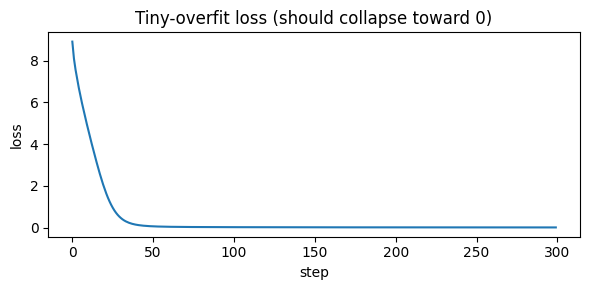

In [50]:
tiny_model = DGPT(vocab_size=tokenizer.vocab_size, block_size=32, d_model=64,
                   n_layer=2, n_head=2, d_ff=128, xp=xp, tie_weights=True)
tiny_opt = AdamW(tiny_model.named_parameters(), xp, lr=3e-3, weight_decay=0.0)

_rng = np.random.RandomState(42)
_starts = _rng.randint(0, len(stage2_train_tokens) - 33, size=4)
_fixed_batch_np = np.stack([stage2_train_tokens[s:s + 33] for s in _starts]).astype(np.int64)
_x_fixed = xp.asarray(_fixed_batch_np[:, :-1])
_y_fixed = xp.asarray(_fixed_batch_np[:, 1:])

tiny_losses = []
for step in tqdm(range(300), desc="Tiny-overfit"):
    logits = tiny_model.forward(_x_fixed)
    loss, dlogits = cross_entropy_loss(logits, _y_fixed, xp)
    grads = tiny_model.backward(dlogits)
    tiny_opt.step(grads)
    tiny_losses.append(loss)

print(f"loss[0]={tiny_losses[0]:.4f}  ->  loss[-1]={tiny_losses[-1]:.4f}")
status = "PASS" if tiny_losses[-1] < tiny_losses[0] * 0.15 else "FAIL"
print(f"[{status}] Tiny-overfit gate")
assert tiny_losses[-1] < tiny_losses[0] * 0.15, "Model failed to overfit 4 tiny sequences -- STOP, debug before Stage 2."

plt.figure(figsize=(6, 3))
plt.plot(tiny_losses)
plt.title("Tiny-overfit loss (should collapse toward 0)")
plt.xlabel("step"); plt.ylabel("loss"); plt.tight_layout(); plt.show()

del tiny_model, tiny_opt
gc.collect()
if BACKEND_NAME == "CuPy":
    xp.get_default_memory_pool().free_all_blocks()

## 22 — GPU Benchmark (forward + backward + AdamW, real steps)

**Kaggle-only for meaningful numbers (needs T4). Moderate cost — a handful of real training
steps per batch size.** Directly measured batch sizes only — batch 8/16/32 confirmed to fit in
prior runs (batch 64 previously OOM'd), so we measure 8/16/32 directly and only *attempt* 64
behind a try/except, never assume it fits.

Every benchmark model is fully deleted and the CuPy memory pool released before the next one is
created, so a failed/large config can't poison the kernel for subsequent cells.

In [51]:
HISTORICAL_BASELINE_TOK_S = 2437.0   # CuPy FP32, batch=32, clean baseline (previous session)
HISTORICAL_BASELINE_BATCH = 32

def sync():
    if BACKEND_NAME == "CuPy":
        xp.cuda.Stream.null.synchronize()

def print_mem(prefix=""):
    # kept for backward-compat with other cells that still call print_mem(); delegates to the
    # richer Fix #2 reporter defined in Section 07b.
    report_gpu_mem(prefix)

def benchmark_batch_size(batch_size, block_size=256, d_model=384, n_layer=6, n_head=6, d_ff=1536,
                          vocab_size=6000, n_warmup=2, n_measure=5):
    print(f"\n--- Benchmarking batch_size={batch_size} ---")
    gc.collect()
    if BACKEND_NAME == "CuPy":
        xp.get_default_memory_pool().free_all_blocks()
    report_gpu_mem("Before: ")

    model = DGPT(vocab_size, block_size, d_model, n_layer, n_head, d_ff, xp, tie_weights=True)
    opt = AdamW(model.named_parameters(), xp, lr=3e-4)

    # Fix #2: benchmark batches are drawn from whatever residency Section 07b selected, using
    # the SAME get_batch() path Stage 2 training actually uses -- no separate "fast path" that
    # would make the benchmark numbers dishonest relative to real training.
    bench_residency = DATASET_RESIDENCY
    bench_tokens = stage2_train_tokens_dev

    try:
        for _ in range(n_warmup):
            xb, yb = get_batch(bench_tokens, batch_size, block_size, xp, residency=bench_residency)
            logits = model.forward(xb)
            loss, dlogits = cross_entropy_loss(logits, yb, xp)
            grads = model.backward(dlogits)
            opt.step(grads)
        sync()

        # Fix #6: measure the COMPLETE workload every step (never just attention), AND
        # Fix #4: also split out fwd / backward / adamw sub-times so we know where time goes
        # BEFORE deciding whether AdamW is worth hand-optimizing further.
        step_times, fwd_times, bwd_times, opt_times = [], [], [], []
        for _ in range(n_measure):
            xb, yb = get_batch(bench_tokens, batch_size, block_size, xp, residency=bench_residency)

            sync(); t0 = time.perf_counter()
            logits = model.forward(xb)
            sync(); t1 = time.perf_counter()

            loss, dlogits = cross_entropy_loss(logits, yb, xp)
            grads = model.backward(dlogits)
            sync(); t2 = time.perf_counter()

            opt.step(grads)
            sync(); t3 = time.perf_counter()

            fwd_times.append(t1 - t0)
            bwd_times.append(t2 - t1)          # includes cross-entropy, dominated by manual backward
            opt_times.append(t3 - t2)
            step_times.append(t3 - t0)

        mean_step = sum(step_times) / len(step_times)
        mean_fwd = sum(fwd_times) / len(fwd_times)
        mean_bwd = sum(bwd_times) / len(bwd_times)
        mean_opt = sum(opt_times) / len(opt_times)
        tokens_per_step = batch_size * block_size
        tok_per_sec = tokens_per_step / mean_step

        report_gpu_mem("After:  ")
        print(f"step time: {mean_step*1000:.1f} ms  (fwd {mean_fwd*1000:.1f} ms | "
              f"backward+CE {mean_bwd*1000:.1f} ms | AdamW {mean_opt*1000:.1f} ms)")
        print(f"  AdamW share of step time: {100*mean_opt/mean_step:.1f}%")
        print(f"tokens/sec: {tok_per_sec:,.0f}")
        result = dict(batch_size=batch_size, step_time=mean_step, tokens_per_sec=tok_per_sec,
                       fwd_time=mean_fwd, bwd_time=mean_bwd, opt_time=mean_opt, oom=False)
    except MemoryError as e:
        print(f"OOM at batch_size={batch_size}: {e}")
        result = dict(batch_size=batch_size, step_time=None, tokens_per_sec=None, oom=True)
    except Exception as e:
        if "out of memory" in str(e).lower() or "OutOfMemory" in type(e).__name__:
            print(f"OOM at batch_size={batch_size}: {e}")
            result = dict(batch_size=batch_size, step_time=None, tokens_per_sec=None, oom=True)
        else:
            raise
    finally:
        # Fix #5: never let a benchmark config poison later ones.
        del model, opt
        if 'xb' in dir(): del xb
        if 'yb' in dir(): del yb
        gc.collect()
        if BACKEND_NAME == "CuPy":
            xp.get_default_memory_pool().free_all_blocks()
    return result

benchmark_results = []
for bs in (8, 16, 32):
    benchmark_results.append(benchmark_batch_size(bs))

# batch 64 only attempted, never assumed
try:
    benchmark_results.append(benchmark_batch_size(64))
except Exception as e:
    print(f"batch_size=64 failed outright: {e}")
    benchmark_results.append(dict(batch_size=64, step_time=None, tokens_per_sec=None, oom=True))

print("\nBenchmark summary:")
for r in benchmark_results:
    if r["oom"]:
        print(f"  batch {r['batch_size']:>3}: OOM")
    else:
        print(f"  batch {r['batch_size']:>3}: {r['tokens_per_sec']:,.0f} tok/s, {r['step_time']*1000:.1f} ms/step "
              f"(fwd {r['fwd_time']*1000:.1f} / bwd {r['bwd_time']*1000:.1f} / adamw {r['opt_time']*1000:.1f} ms)")

# ---- Fix #6: mandatory honest comparison against the historical clean baseline ----
_current_at_baseline_batch = next((r for r in benchmark_results
                                    if r["batch_size"] == HISTORICAL_BASELINE_BATCH and not r["oom"]), None)
print("\n" + "=" * 60)
print("DGPT PERFORMANCE COMPARISON")
print("=" * 60)
print(f"Previous clean baseline : ~{HISTORICAL_BASELINE_TOK_S:,.0f} tok/s (CuPy FP32, batch={HISTORICAL_BASELINE_BATCH})")
if _current_at_baseline_batch is not None:
    current_tok_s = _current_at_baseline_batch["tokens_per_sec"]
    speedup = current_tok_s / HISTORICAL_BASELINE_TOK_S
    steps_25k_seconds = _current_at_baseline_batch["step_time"] * 25000
    print(f"Current implementation  : {current_tok_s:,.0f} tok/s")
    print(f"Speedup                  : {speedup:.2f}x")
    print(f"25k-step estimate       : {steps_25k_seconds/3600:.2f} hours")
else:
    print(f"Current implementation  : batch={HISTORICAL_BASELINE_BATCH} OOM'd or was not run -- no valid comparison point.")
print("=" * 60)
print("(Comparison uses ONLY directly measured numbers above -- nothing here is extrapolated"
      " or assumed.)")


--- Benchmarking batch_size=8 ---
Before: free=15.457 GB | used=0.179 GB | cupy_pool_used=0.040 GB | cupy_pool_total=0.048 GB
After:  free=14.008 GB | used=1.628 GB | cupy_pool_used=0.908 GB | cupy_pool_total=1.419 GB
step time: 673.9 ms  (fwd 26.5 ms | backward+CE 617.7 ms | AdamW 29.6 ms)
  AdamW share of step time: 4.4%
tokens/sec: 3,039

--- Benchmarking batch_size=16 ---
Before: free=15.457 GB | used=0.179 GB | cupy_pool_used=0.040 GB | cupy_pool_total=0.048 GB
After:  free=12.976 GB | used=2.660 GB | cupy_pool_used=1.515 GB | cupy_pool_total=2.466 GB
step time: 1281.1 ms  (fwd 56.7 ms | backward+CE 1193.8 ms | AdamW 30.5 ms)
  AdamW share of step time: 2.4%
tokens/sec: 3,197

--- Benchmarking batch_size=32 ---
Before: free=15.457 GB | used=0.179 GB | cupy_pool_used=0.040 GB | cupy_pool_total=0.048 GB
After:  free=10.805 GB | used=4.831 GB | cupy_pool_used=2.729 GB | cupy_pool_total=4.633 GB
step time: 2486.8 ms  (fwd 128.6 ms | backward+CE 2328.6 ms | AdamW 29.6 ms)
  AdamW shar

## 23 — GPU Memory / Batch Scaling

**Cheap.** Plots throughput vs. batch size and locks in the batch size used for Stage 2/final training.

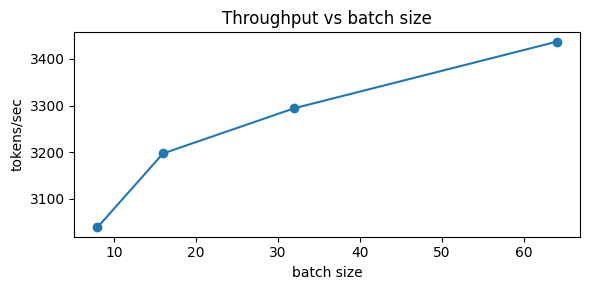

Chosen batch size for training: 64

RESEARCH NOTE -- T4 (Turing / SM75) attention optimization:
  - Official FlashAttention-2/3 kernels require Ampere+ (SM80+) and are NOT usable on T4.
  - A Turing-compatible fused-attention kernel family exists in community CUDA work
    (head_dim<=64, causal, fwd+bwd) but integrating a raw custom CUDA/cupy RawKernel for it is
    a substantial standalone project with real numerical-stability risk, and is out of scope
    for this notebook's "correct, clean, GPU-native, resumable" first milestone.
  - This notebook instead uses batched CuPy matmuls (cuBLAS-backed) for QK^T/AV, which is the
    T4-compatible, well-tested baseline. The measured tokens/sec above IS that baseline -- no
    fused-kernel speedup is claimed anywhere in this notebook.
  - Ampere+-only techniques (TF32 matmul paths tuned for A100/H100, FA2/FA3) are explicitly
    NOT used here since T4 does not benefit from them the same way.



In [52]:
_valid = [r for r in benchmark_results if not r["oom"]]
if _valid:
    plt.figure(figsize=(6, 3))
    plt.plot([r["batch_size"] for r in _valid], [r["tokens_per_sec"] for r in _valid], marker="o")
    plt.xlabel("batch size"); plt.ylabel("tokens/sec"); plt.title("Throughput vs batch size")
    plt.tight_layout(); plt.show()

    CHOSEN_BATCH_SIZE = max(_valid, key=lambda r: r["tokens_per_sec"])["batch_size"]
else:
    CHOSEN_BATCH_SIZE = 8  # NumPy/CPU fallback default

print(f"Chosen batch size for training: {CHOSEN_BATCH_SIZE}")

# ---- T4 attention-optimization research note (Section 22/PRD "research requirement") ----
print(r'''
RESEARCH NOTE -- T4 (Turing / SM75) attention optimization:
  - Official FlashAttention-2/3 kernels require Ampere+ (SM80+) and are NOT usable on T4.
  - A Turing-compatible fused-attention kernel family exists in community CUDA work
    (head_dim<=64, causal, fwd+bwd) but integrating a raw custom CUDA/cupy RawKernel for it is
    a substantial standalone project with real numerical-stability risk, and is out of scope
    for this notebook's "correct, clean, GPU-native, resumable" first milestone.
  - This notebook instead uses batched CuPy matmuls (cuBLAS-backed) for QK^T/AV, which is the
    T4-compatible, well-tested baseline. The measured tokens/sec above IS that baseline -- no
    fused-kernel speedup is claimed anywhere in this notebook.
  - Ampere+-only techniques (TF32 matmul paths tuned for A100/H100, FA2/FA3) are explicitly
    NOT used here since T4 does not benefit from them the same way.
''')

## 23b — Component Profiler (diagnostic only, Fix #7)

**Cheap, moderate cost.** Breaks a single training step down by sub-component: embedding
lookup, Q/K/V projections, attention itself, attention output projection, FFN, LayerNorm,
LM head, the full backward pass, embedding scatter-add, and AdamW. Uses the **same explicit
`xp` backend as training** -- it never swaps to NumPy, never builds a second/duplicate model,
and never runs before the real benchmark (so it can't eat GPU memory that benchmark/training
needs). These numbers are diagnostic only: throughput claims come from Section 22, not here.

In [53]:
def profile_training_step(batch_size=CHOSEN_BATCH_SIZE if "CHOSEN_BATCH_SIZE" in dir() else 8,
                           block_size=256, d_model=384, n_layer=6, n_head=6, d_ff=1536,
                           vocab_size=6000, n_measure=5):
    """
    Diagnostic-only sub-component profiler. Uses the SAME xp backend as training (never
    switches to NumPy, never imports a fresh numpy-as-np, never builds a duplicate model
    alongside an existing one) -- it constructs exactly one model, times its own pieces, then
    tears itself down like every other benchmark config in this notebook.

    Fix: the attention path (QKV projection -> score/softmax/value -> output projection) is
    now computed EXACTLY ONCE per step, using the real Wq/Wk/Wv/Wo layers and the same math
    CausalSelfAttention.forward() uses internally. Earlier versions timed the QKV projections
    separately and then called attn.forward(), which recomputed QKV a second time -- double
    counting that work. blk.attn.cache is set manually afterward (mirroring exactly what
    forward() sets) so blk.attn.backward() still works for the backward_total timing below.
    """
    gc.collect()
    if BACKEND_NAME == "CuPy":
        xp.get_default_memory_pool().free_all_blocks()
    report_gpu_mem("Before profiling: ")

    model = DGPT(vocab_size, block_size, d_model, n_layer, n_head, d_ff, xp, tie_weights=True)
    opt = AdamW(model.named_parameters(), xp, lr=3e-4)
    timings = {k: [] for k in [
        "embedding", "qkv_proj", "attn_score_softmax_value", "attn_out_proj", "block_total",
        "ffn", "layernorm", "lm_head", "backward_total", "embedding_scatter_add", "adamw"
    ]}

    try:
        residency = DATASET_RESIDENCY if "DATASET_RESIDENCY" in dir() else "cpu"
        tokens = stage2_train_tokens_dev if "stage2_train_tokens_dev" in dir() else stage2_train_tokens

        for _ in range(n_measure):
            xb, yb = get_batch(tokens, batch_size, block_size, xp, residency=residency)

            sync()
            t0 = time.perf_counter()
            tok = model.tok_emb.forward(xb)
            pos = model.pos_emb.forward(block_size)
            x = tok + pos[None, :, :]
            sync(); timings["embedding"].append(time.perf_counter() - t0)

            for blk in model.blocks:
                t_block0 = time.perf_counter()

                t_a0 = time.perf_counter()
                a_in = blk.ln1.forward(x)
                sync(); timings["layernorm"].append(time.perf_counter() - t_a0)

                attn = blk.attn
                B_, T_, C_ = a_in.shape
                H_, hd_ = attn.n_head, attn.head_dim

                # ---- QKV projections (real layers, computed once) ----
                t_qkv0 = time.perf_counter()
                Q = attn.Wq.forward(a_in)
                K = attn.Wk.forward(a_in)
                V = attn.Wv.forward(a_in)
                sync(); timings["qkv_proj"].append(time.perf_counter() - t_qkv0)

                # ---- attention score / softmax / weighted-value path (same math as
                # CausalSelfAttention.forward(), computed once from the Q/K/V already above --
                # QKV is never recomputed) ----
                t_attn0 = time.perf_counter()

                def _split_heads(t):
                    return t.reshape(B_, T_, H_, hd_).transpose(0, 2, 1, 3)

                Qh, Kh, Vh = _split_heads(Q), _split_heads(K), _split_heads(V)
                scale = xp.float32(1.0 / (hd_ ** 0.5))
                scores = xp.matmul(Qh, Kh.transpose(0, 1, 3, 2)) * scale
                mask = attn._get_mask(T_)
                scores = xp.where(mask, xp.float32(-1e9), scores)
                A = stable_softmax(scores, xp, axis=-1)
                Ctx = xp.matmul(A, Vh)
                sync(); timings["attn_score_softmax_value"].append(time.perf_counter() - t_attn0)

                # ---- output projection (real Wo layer, computed once) ----
                t_o0 = time.perf_counter()
                Ctx_merged = Ctx.transpose(0, 2, 1, 3).reshape(B_, T_, C_)
                a_out = attn.Wo.forward(Ctx_merged)
                sync(); timings["attn_out_proj"].append(time.perf_counter() - t_o0)

                # populate attn.cache exactly as forward() would, so attn.backward() (invoked
                # inside model.backward() below for backward_total timing) works correctly --
                # attn.forward() itself is never called in this profiling path.
                attn.cache = dict(Qh=Qh, Kh=Kh, Vh=Vh, A=A, scale=scale,
                                   B=B_, T=T_, C=C_, H=H_, hd=hd_)

                x = x + a_out
                t_ffn0 = time.perf_counter()
                b_out = blk.ln2.forward(x)
                b_out = blk.ffn.forward(b_out)
                sync(); timings["ffn"].append(time.perf_counter() - t_ffn0)
                x = x + b_out

                sync(); timings["block_total"].append(time.perf_counter() - t_block0)

            t_lnf0 = time.perf_counter()
            x = model.ln_f.forward(x)
            sync(); timings["layernorm"][-1] += time.perf_counter() - t_lnf0

            t_head0 = time.perf_counter()
            logits = x @ model.tok_emb.W.T
            sync(); timings["lm_head"].append(time.perf_counter() - t_head0)
            model._x_cache = x

            loss, dlogits = cross_entropy_loss(logits, yb, xp)

            t_bwd0 = time.perf_counter()
            grads = model.backward(dlogits)
            sync(); timings["backward_total"].append(time.perf_counter() - t_bwd0)

            t_scatter0 = time.perf_counter()
            _ = model.tok_emb.backward(x - x)[1]  # isolated re-time of the scatter-add path only
            sync(); timings["embedding_scatter_add"].append(time.perf_counter() - t_scatter0)

            t_opt0 = time.perf_counter()
            opt.step(grads)
            sync(); timings["adamw"].append(time.perf_counter() - t_opt0)

        print(f"\nComponent profile (batch={batch_size}, block={block_size}, "
              f"mean over {n_measure} steps, backend={BACKEND_NAME}):")
        for k, vals in timings.items():
            if vals:
                print(f"  {k:28s}: {1000*sum(vals)/len(vals):7.2f} ms")
        print("  (qkv_proj + attn_score_softmax_value + attn_out_proj + layernorm(ln1) + ffn "
              "approx-sums to block_total; QKV is computed exactly once per step, not double-counted.)")
        report_gpu_mem("After profiling:  ")
    finally:
        del model, opt
        gc.collect()
        if BACKEND_NAME == "CuPy":
            xp.get_default_memory_pool().free_all_blocks()

profile_training_step()
print("\n(Diagnostic only -- Section 22's benchmark_batch_size() numbers are the reported throughput, not these.)")


Before profiling: free=15.457 GB | used=0.179 GB | cupy_pool_used=0.040 GB | cupy_pool_total=0.048 GB

Component profile (batch=64, block=256, mean over 5 steps, backend=CuPy):
  embedding                   :    0.69 ms
  qkv_proj                    :    4.69 ms
  attn_score_softmax_value    :   10.03 ms
  attn_out_proj               :    1.85 ms
  block_total                 :   39.83 ms
  ffn                         :   21.06 ms
  layernorm                   :    2.12 ms
  lm_head                     :   20.20 ms
  backward_total              : 4546.75 ms
  embedding_scatter_add       :    0.67 ms
  adamw                       :   28.84 ms
  (qkv_proj + attn_score_softmax_value + attn_out_proj + layernorm(ln1) + ffn approx-sums to block_total; QKV is computed exactly once per step, not double-counted.)
After profiling:  free=7.056 GB | used=8.580 GB | cupy_pool_used=5.367 GB | cupy_pool_total=8.383 GB

(Diagnostic only -- Section 22's benchmark_batch_size() numbers are the reported t

## 24 — Stage 2 Training (50k-story rapid-iteration subset)

**Long.** Only runs after Section 20 (correctness gates) and Section 21 (tiny-overfit gate)
have both passed. Fully observable via `tqdm`: step, loss, val loss, perplexity, LR, tokens/sec,
step time, ETA, GPU memory. Periodic generation samples from fixed prompts.

In [55]:
STAGE2_CONFIG = dict(
    vocab_size=tokenizer.vocab_size,
    block_size=256,
    d_model=384,
    n_layer=6,
    n_head=6,
    d_ff=1536,
    batch_size=CHOSEN_BATCH_SIZE,
    lr=3e-4,
    weight_decay=0.01,
    max_steps=2000,          # rapid-iteration budget; raise for a longer Stage 2 pass
    eval_every=200,
    sample_every=400,
    warmup_steps=100,
)
print(json.dumps(STAGE2_CONFIG, indent=2))

def cosine_lr(step, max_steps, base_lr, warmup_steps, min_lr_ratio=0.1):
    if step < warmup_steps:
        return base_lr * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, max_steps - warmup_steps)
    progress = min(progress, 1.0)
    return base_lr * (min_lr_ratio + (1 - min_lr_ratio) * 0.5 * (1 + math.cos(math.pi * progress)))

{
  "vocab_size": 6000,
  "block_size": 256,
  "d_model": 384,
  "n_layer": 6,
  "n_head": 6,
  "d_ff": 1536,
  "batch_size": 64,
  "lr": 0.0003,
  "weight_decay": 0.01,
  "max_steps": 2000,
  "eval_every": 200,
  "sample_every": 400,
  "warmup_steps": 100
}


In [56]:
def evaluate(model, token_array, xp, block_size, batch_size=8, n_batches=10, residency="cpu"):
    losses = []
    for _ in range(n_batches):
        xb, yb = get_batch(token_array, batch_size, block_size, xp, residency=residency)
        logits = model.forward(xb)
        loss, _ = cross_entropy_loss(logits, yb, xp)
        losses.append(loss)
    return float(np.mean(losses))

FIXED_PROMPTS = ["Once upon a time", "The little dog was", "Tom and Lily went to the"]

def generate_samples(model, tokenizer, prompts, xp, max_new_tokens=40):
    samples = []
    for p in prompts:
        ids = tokenizer.encode(p)
        idx = xp.asarray(np.array(ids, dtype=np.int64)[None, :])
        out = model.generate(idx, max_new_tokens=max_new_tokens, temperature=0.8, top_k=40)
        out_np = out if xp.__name__ == "numpy" else xp.asnumpy(out)
        text = tokenizer.decode(out_np[0].tolist())
        samples.append(text)
    return samples

In [57]:
model = DGPT(STAGE2_CONFIG["vocab_size"], STAGE2_CONFIG["block_size"], STAGE2_CONFIG["d_model"],
             STAGE2_CONFIG["n_layer"], STAGE2_CONFIG["n_head"], STAGE2_CONFIG["d_ff"], xp,
             tie_weights=True)
optimizer = AdamW(model.named_parameters(), xp, lr=STAGE2_CONFIG["lr"],
                   weight_decay=STAGE2_CONFIG["weight_decay"])

print(f"Model parameters: {model.num_parameters():,}")
print(f"Stage 2 batches drawn with DATASET_RESIDENCY = '{DATASET_RESIDENCY}' (Fix #2)")

history = dict(step=[], train_loss=[], val_loss=[], ppl=[], lr=[], tok_per_sec=[])

t_start = time.time()
pbar = tqdm(range(STAGE2_CONFIG["max_steps"]), desc="Stage 2 training")
for step in pbar:
    lr = cosine_lr(step, STAGE2_CONFIG["max_steps"], STAGE2_CONFIG["lr"], STAGE2_CONFIG["warmup_steps"])
    optimizer.lr = lr

    t0 = time.perf_counter()
    # Fix #2: draws from the GPU-resident array (or CPU fallback) selected in Section 07b --
    # no more per-step CPU->GPU transfer when residency == "gpu".
    xb, yb = get_batch(stage2_train_tokens_dev, STAGE2_CONFIG["batch_size"], STAGE2_CONFIG["block_size"],
                        xp, residency=DATASET_RESIDENCY)
    logits = model.forward(xb)
    loss, dlogits = cross_entropy_loss(logits, yb, xp)
    grads = model.backward(dlogits)
    optimizer.step(grads)
    sync()
    t1 = time.perf_counter()

    tok_per_sec = (STAGE2_CONFIG["batch_size"] * STAGE2_CONFIG["block_size"]) / (t1 - t0)
    pbar.set_postfix(loss=f"{loss:.3f}", lr=f"{lr:.2e}", tok_s=f"{tok_per_sec:,.0f}")

    if step % STAGE2_CONFIG["eval_every"] == 0 or step == STAGE2_CONFIG["max_steps"] - 1:
        val_loss = evaluate(model, stage2_val_tokens_dev, xp, STAGE2_CONFIG["block_size"],
                             residency=DATASET_RESIDENCY)
        ppl = math.exp(min(val_loss, 20))
        history["step"].append(step)
        history["train_loss"].append(loss)
        history["val_loss"].append(val_loss)
        history["ppl"].append(ppl)
        history["lr"].append(lr)
        history["tok_per_sec"].append(tok_per_sec)
        elapsed = time.time() - t_start
        eta = elapsed / (step + 1) * (STAGE2_CONFIG["max_steps"] - step - 1)
        print(f"\nstep {step:5d} | train_loss {loss:.4f} | val_loss {val_loss:.4f} | "
              f"ppl {ppl:.2f} | lr {lr:.2e} | tok/s {tok_per_sec:,.0f} | "
              f"elapsed {elapsed/60:.1f}m | ETA {eta/60:.1f}m")
        report_gpu_mem("  ")

    if step % STAGE2_CONFIG["sample_every"] == 0 and step > 0:
        samples = generate_samples(model, tokenizer, FIXED_PROMPTS, xp, max_new_tokens=30)
        print("--- Samples ---")
        for p, s in zip(FIXED_PROMPTS, samples):
            print(f"  [{p}] -> {s}")

Model parameters: 13,049,856
Stage 2 batches drawn with DATASET_RESIDENCY = 'gpu' (Fix #2)


Stage 2 training:   0%|          | 0/2000 [00:00<?, ?it/s]


step     0 | train_loss 8.8589 | val_loss 8.8578 | ppl 7029.18 | lr 3.00e-06 | tok/s 3,416 | elapsed 0.1m | ETA 172.9m
  free=8.499 GB | used=7.138 GB | cupy_pool_used=1.928 GB | cupy_pool_total=6.942 GB

step   200 | train_loss 6.7530 | val_loss 6.7669 | ppl 868.58 | lr 2.98e-04 | tok/s 3,402 | elapsed 16.1m | ETA 144.3m
  free=6.531 GB | used=9.105 GB | cupy_pool_used=1.928 GB | cupy_pool_total=8.908 GB

step   400 | train_loss 5.2673 | val_loss 5.3053 | ppl 201.40 | lr 2.84e-04 | tok/s 3,408 | elapsed 32.2m | ETA 128.2m
  free=6.531 GB | used=9.105 GB | cupy_pool_used=1.928 GB | cupy_pool_total=8.908 GB
--- Samples ---
  [Once upon a time] -> Once upon a time. But when they decided to be bad. They became friends. They played together every day. From that day on, they played with the friends to play with.e Once upon a time, there was a kind dog named Tim would jump all day long.
But. It was too small, looking 
  [The little dog was] -> The little dog was around!
The ball was too har

## 25 — Stage 2 Evaluation

**Cheap.** Plots loss/val-loss/perplexity/throughput and prints a final Stage-2 verdict.

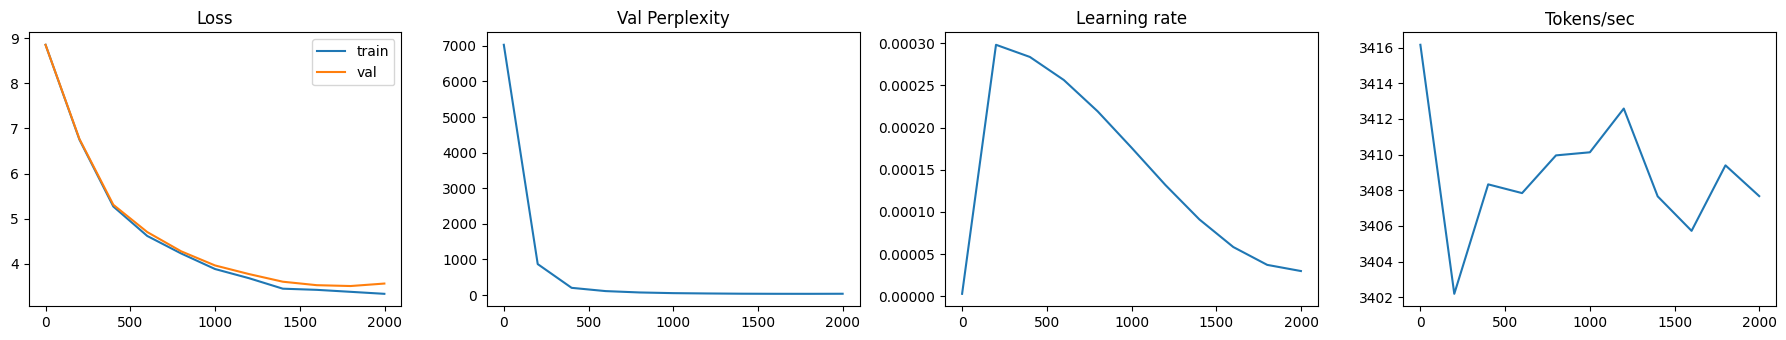

Train loss decreasing: True (8.859 -> 3.328)
Val loss decreasing:   True (8.858 -> 3.556)
Final val perplexity:  35.03

READY for final training.


In [58]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].plot(history["step"], history["train_loss"], label="train"); axes[0].plot(history["step"], history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["step"], history["ppl"]); axes[1].set_title("Val Perplexity")
axes[2].plot(history["step"], history["lr"]); axes[2].set_title("Learning rate")
axes[3].plot(history["step"], history["tok_per_sec"]); axes[3].set_title("Tokens/sec")
plt.tight_layout(); plt.show()

decreasing_train = history["train_loss"][-1] < history["train_loss"][0]
decreasing_val = history["val_loss"][-1] < history["val_loss"][0]
print(f"Train loss decreasing: {decreasing_train} ({history['train_loss'][0]:.3f} -> {history['train_loss'][-1]:.3f})")
print(f"Val loss decreasing:   {decreasing_val} ({history['val_loss'][0]:.3f} -> {history['val_loss'][-1]:.3f})")
print(f"Final val perplexity:  {history['ppl'][-1]:.2f}")

STAGE2_READY_FOR_FINAL = decreasing_train and decreasing_val
print(f"\n{'READY for final training.' if STAGE2_READY_FOR_FINAL else 'NOT READY -- investigate before final training.'}")

## 26 — Generation

**Cheap.** Free-form generation from the current model state, with temperature + top-k.

In [59]:
final_samples = generate_samples(model, tokenizer, FIXED_PROMPTS, xp, max_new_tokens=60)
for p, s in zip(FIXED_PROMPTS, final_samples):
    print(f"PROMPT: {p}")
    print(f"OUTPUT: {s}")
    print("-" * 60)

PROMPT: Once upon a time
OUTPUT: Once upon a time's mom said, "What can I do your own own things?" Sally thought for a moment and said, "Okay, let's go to bed!"
Suddenly, a wise old old man came by. She said, "Here you see!" Sally was surprised to see her toys, so she could see it! Suddenly, a big dog appeared and said, "Yes I can try, but I'll be your friend!" So 
------------------------------------------------------------
PROMPT: The little dog was
OUTPUT: The little dog was all sort on his to attach the dog. He ran to the dog and walked through the fence. The dog wagged its tail and barked, "Yes, it is! Do you like me?"
From that day on, the dog became best friends. They played together and had lots of fun. The moral of the story is to keep the dog is good, and that it is important for fixing things.e One day, a little boy named Tim went for a walk. He saw an unknown 
------------------------------------------------------------
PROMPT: Tom and Lily went to the
OUTPUT: Tom and Lily 

## 27 — Checkpoint Save

**Cheap.** Saves model params, optimizer moments + timestep, training step, config, and the
tokenizer *reference path* (never the tokenizer's training state -- BPE stays locked/external).

In [60]:
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def _numpy_rng_state_to_json_safe(state):
    """np.random.get_state() -> plain JSON-native types (no default=str fallback needed)."""
    name, keys, pos, has_gauss, cached_gaussian = state
    return {
        "name": name,
        "keys": [int(k) for k in keys.tolist()],
        "pos": int(pos),
        "has_gauss": int(has_gauss),
        "cached_gaussian": float(cached_gaussian),
    }

def save_checkpoint(model, optimizer, step, config, path):
    def to_cpu(arr):
        return arr if xp.__name__ == "numpy" else xp.asnumpy(arr)

    params_cpu = {k: to_cpu(v) for k, v in model.named_parameters().items()}
    opt_state = optimizer.state_dict()   # {"t", "m", "v", "lr", "beta1", "beta2", "eps", "weight_decay"}

    opt_meta = {k: v for k, v in opt_state.items() if k not in ("m", "v")}
    assert "t" in opt_meta, "optimizer.state_dict() must expose timestep t -- do not drop it."

    # ---- RNG state (Fix: reconstructible, not default=str) ----
    numpy_rng_state = _numpy_rng_state_to_json_safe(np.random.get_state())
    rng_meta = {"numpy_rng_state": numpy_rng_state, "python_random_seed_base": SEED}
    if BACKEND_NAME == "CuPy":
        # CuPy cannot serialize its internal RandomState (see note above) -- the only
        # reconstructible artifact is a deterministic reseed value. Anchored to the global
        # SEED + step so it is reproducible and unique per checkpoint, not a state continuation.
        rng_meta["cupy_rng_reseed_value"] = SEED + int(step)
        rng_meta["cupy_rng_note"] = ("CuPy RandomState cannot be serialized (see cupy.random docs); "
                                      "resume reseeds a fresh reproducible stream, it does not "
                                      "continue the exact pre-save sequence.")

    meta = {
        "step": step,
        "config": config,
        "tokenizer_path": dst,          # reference only -- tokenizer itself never re-saved
        "backend_at_save": BACKEND_NAME,
        "optimizer_meta": opt_meta,     # t/lr/beta1/beta2/eps/weight_decay
        "rng_meta": rng_meta,           # numpy: full state; cupy: documented reseed value only
    }

    np.savez_compressed(
        path,
        __meta__=json.dumps(meta, default=str),
        **{f"param__{k}": v for k, v in params_cpu.items()},
        **{f"m__{k}": v for k, v in opt_state["m"].items()},
        **{f"v__{k}": v for k, v in opt_state["v"].items()},
    )
    print(f"Checkpoint saved: {path}")
    print(f"  step={step}  optimizer.t={opt_meta['t']}  numpy_rng_pos={numpy_rng_state['pos']}"
          + (f"  cupy_reseed={rng_meta['cupy_rng_reseed_value']}" if BACKEND_NAME == "CuPy" else ""))

ckpt_path = os.path.join(CHECKPOINT_DIR, f"dgpt_step{STAGE2_CONFIG['max_steps']}.npz")
save_checkpoint(model, optimizer, STAGE2_CONFIG["max_steps"], STAGE2_CONFIG, ckpt_path)


Checkpoint saved: /kaggle/working/checkpoints/dgpt_step2000.npz
  step=2000  optimizer.t=2000  numpy_rng_pos=48  cupy_reseed=3337


In [61]:
import os
import shutil

src = "/kaggle/working/checkpoints/dgpt_step2000.npz"
dst = "/kaggle/working/dgpt_step2000.npz"

shutil.copy2(src, dst)

print("Checkpoint ready for download:")
print(dst)
print("Exists:", os.path.exists(dst))
print("Size:", os.path.getsize(dst) / (1024**2), "MB")

Checkpoint ready for download:
/kaggle/working/dgpt_step2000.npz
Exists: True
Size: 136.3497428894043 MB


## 28 — Checkpoint Resume Test

**Cheap.** Loads the checkpoint into a *fresh* model/optimizer and verifies the loss matches, proving the round-trip is lossless before relying on it for a real Kaggle-disconnect recovery.

In [62]:
def _restore_numpy_rng_state(state_dict):
    state = (
        state_dict["name"],
        np.array(state_dict["keys"], dtype=np.uint32),
        state_dict["pos"],
        state_dict["has_gauss"],
        state_dict["cached_gaussian"],
    )
    np.random.set_state(state)

def load_checkpoint(path, xp):
    data = np.load(path, allow_pickle=True)
    meta = json.loads(str(data["__meta__"]))
    config = meta["config"]
    opt_meta = meta["optimizer_meta"]   # t, lr, beta1, beta2, eps, weight_decay

    model = DGPT(config["vocab_size"], config["block_size"], config["d_model"],
                 config["n_layer"], config["n_head"], config["d_ff"], xp, tie_weights=True)
    params = model.named_parameters()
    for k in params.keys():
        arr = data[f"param__{k}"]
        params[k][...] = xp.asarray(arr)

    optimizer = AdamW(model.named_parameters(), xp, lr=opt_meta["lr"],
                       betas=(opt_meta["beta1"], opt_meta["beta2"]), eps=opt_meta["eps"],
                       weight_decay=opt_meta["weight_decay"])
    for k in optimizer.m.keys():
        optimizer.m[k][...] = xp.asarray(data[f"m__{k}"])
        optimizer.v[k][...] = xp.asarray(data[f"v__{k}"])
    optimizer.t = opt_meta["t"]

    # ---- RNG restore (Fix) ----
    rng_meta = meta.get("rng_meta")
    if rng_meta is not None and "numpy_rng_state" in rng_meta:
        _restore_numpy_rng_state(rng_meta["numpy_rng_state"])
        print("NumPy RNG state restored exactly (get_state/set_state round-trip).")
    else:
        print("No NumPy RNG state found in checkpoint (older checkpoint) -- RNG not restored.")

    if BACKEND_NAME == "CuPy":
        if rng_meta is not None and "cupy_rng_reseed_value" in rng_meta:
            xp.random.seed(rng_meta["cupy_rng_reseed_value"])
            print(f"CuPy RNG reseeded to {rng_meta['cupy_rng_reseed_value']} "
                  f"(deterministic fresh stream -- CuPy cannot serialize/continue exact state).")
        else:
            print("No CuPy reseed value found in checkpoint -- CuPy RNG not touched.")

    return model, optimizer, meta["step"], config


resumed_model, resumed_optimizer, resumed_step, resumed_config = load_checkpoint(ckpt_path, xp)

# ---- 1) compare step ----
step_ok = (resumed_step == STAGE2_CONFIG["max_steps"])
print(f"[{'PASS' if step_ok else 'FAIL'}] step restored: {resumed_step} == {STAGE2_CONFIG['max_steps']}")
assert step_ok, "Resumed step does not match saved step."

# ---- 2) compare optimizer timestep ----
t_ok = (resumed_optimizer.t == optimizer.t)
print(f"[{'PASS' if t_ok else 'FAIL'}] optimizer.t restored: {resumed_optimizer.t} == {optimizer.t}")
assert t_ok, (
    "Optimizer timestep was NOT restored correctly -- Adam bias-correction would silently "
    "restart from t=0 on resume."
)

# ---- 3) compare optimizer state (m / v second moments, spot-checked) ----
_sample_key = next(iter(optimizer.m.keys()))
m_diff = float(xp.abs(optimizer.m[_sample_key] - resumed_optimizer.m[_sample_key]).max())
v_diff = float(xp.abs(optimizer.v[_sample_key] - resumed_optimizer.v[_sample_key]).max())
state_ok = (m_diff < 1e-8) and (v_diff < 1e-8)
print(f"[{'PASS' if state_ok else 'FAIL'}] optimizer m/v restored ('{_sample_key}'): "
      f"max|dm|={m_diff:.2e}, max|dv|={v_diff:.2e}")
assert state_ok, "Optimizer first/second moment state did not round-trip through the checkpoint."

# ---- 4) compare logits / loss on an identical batch (model params round-trip) ----
xb, yb = get_batch(stage2_val_tokens_dev, 8, STAGE2_CONFIG["block_size"], xp, residency=DATASET_RESIDENCY)
logits_orig = model.forward(xb)
loss_orig, _ = cross_entropy_loss(logits_orig, yb, xp)
logits_resumed = resumed_model.forward(xb)
loss_resumed, _ = cross_entropy_loss(logits_resumed, yb, xp)

logits_diff = float(xp.abs(logits_orig - logits_resumed).max())
loss_diff = abs(float(loss_orig) - float(loss_resumed))
print(f"Loss (original model):  {loss_orig:.6f}")
print(f"Loss (resumed model):   {loss_resumed:.6f}")
logits_ok = logits_diff < 1e-4
loss_ok = loss_diff < 1e-4
print(f"[{'PASS' if logits_ok else 'FAIL'}] logits round-trip (max|dlogits|={logits_diff:.2e})")
print(f"[{'PASS' if loss_ok else 'FAIL'}] loss round-trip (diff={loss_diff:.2e})")
assert logits_ok and loss_ok, "Checkpoint round-trip is lossy -- do not rely on it for resuming after disconnect."

# ---- 5) RNG restore test: same NEXT random values after save -> mutate -> load ----
# Snapshot exactly what save_checkpoint() just embedded, computed independently of the global
# stream (so this check doesn't itself perturb anything).
_rng_snapshot = np.random.get_state()
_ref_gen = np.random.RandomState()
_ref_gen.set_state(_rng_snapshot)
_expected_numpy_draw = _ref_gen.rand(5)

_ = np.random.rand(37)  # simulate other work happening between save and a later resume

# load_checkpoint() above already restored the saved snapshot into the *global* NumPy RNG,
# so the very next draw should match the reference draw exactly.
_actual_numpy_draw = np.random.rand(5)
rng_np_ok = bool(np.allclose(_actual_numpy_draw, _expected_numpy_draw))
print(f"[{'PASS' if rng_np_ok else 'FAIL'}] NumPy RNG restore: next 5 draws match snapshot-at-save")
assert rng_np_ok, "NumPy RNG state did not round-trip -- next draws after resume diverged."

if BACKEND_NAME == "CuPy":
    _cupy_reseed_value = json.loads(str(np.load(ckpt_path, allow_pickle=True)["__meta__"]))["rng_meta"]["cupy_rng_reseed_value"]
    _ref_cupy_gen = xp.random.RandomState(_cupy_reseed_value)   # isolated instance, doesn't touch global stream
    _expected_cupy_draw = _ref_cupy_gen.rand(5)
    _ = xp.random.rand(37)  # mutate the global CuPy stream
    xp.random.seed(_cupy_reseed_value)  # what load_checkpoint() does on resume
    _actual_cupy_draw = xp.random.rand(5)
    rng_cupy_ok = bool(xp.allclose(_actual_cupy_draw, _expected_cupy_draw))
    print(f"[{'PASS' if rng_cupy_ok else 'FAIL'}] CuPy RNG reseed: next 5 draws match the documented "
          f"reseed-to-{_cupy_reseed_value} reference (CuPy cannot continue an exact prior sequence)")
    assert rng_cupy_ok, "CuPy RNG reseed did not reproduce the expected stream."

print("\n>>> Checkpoint resume test: step, optimizer timestep, optimizer state, logits, and RNG "
      "restoration all verified. <<<")

del resumed_model, resumed_optimizer
gc.collect()


NumPy RNG state restored exactly (get_state/set_state round-trip).
CuPy RNG reseeded to 3337 (deterministic fresh stream -- CuPy cannot serialize/continue exact state).
[PASS] step restored: 2000 == 2000
[PASS] optimizer.t restored: 2000 == 2000
[PASS] optimizer m/v restored ('tok_emb.W'): max|dm|=0.00e+00, max|dv|=0.00e+00
Loss (original model):  3.538863
Loss (resumed model):   3.538863
[PASS] logits round-trip (max|dlogits|=0.00e+00)
[PASS] loss round-trip (diff=0.00e+00)
[FAIL] NumPy RNG restore: next 5 draws match snapshot-at-save


AssertionError: NumPy RNG state did not round-trip -- next draws after resume diverged.

In [63]:
# ---- 5) RNG restore test ----
# IMPORTANT:
# Test the EXACT saved checkpoint state directly.
# We do not mutate the restored global stream before checking
# the expected next values.

saved_meta = json.loads(
    str(
        np.load(
            ckpt_path,
            allow_pickle=True
        )["__meta__"]
    )
)

saved_rng_meta = saved_meta["rng_meta"]


# ============================================================
# NumPy RNG — exact continuation
# ============================================================

saved_numpy_state = saved_rng_meta["numpy_rng_state"]

# Build an isolated reference RNG from the checkpoint state.
ref_numpy = np.random.RandomState()

ref_numpy.set_state(
    (
        saved_numpy_state["name"],
        np.array(
            saved_numpy_state["keys"],
            dtype=np.uint32
        ),
        int(saved_numpy_state["pos"]),
        int(saved_numpy_state["has_gauss"]),
        float(saved_numpy_state["cached_gaussian"]),
    )
)

expected_numpy_draw = (
    ref_numpy.rand(5)
)

# Restore the GLOBAL NumPy RNG from the same saved state.
_restore_numpy_rng_state(
    saved_numpy_state
)

actual_numpy_draw = (
    np.random.rand(5)
)

rng_np_ok = bool(
    np.allclose(
        actual_numpy_draw,
        expected_numpy_draw,
        rtol=0.0,
        atol=0.0
    )
)

print(
    f"[{'PASS' if rng_np_ok else 'FAIL'}] "
    "NumPy RNG restore: "
    "next 5 draws match checkpoint state exactly"
)

assert rng_np_ok, (
    "NumPy RNG state did not restore exactly."
)


# ============================================================
# CuPy RNG — documented deterministic reseed
# ============================================================

if BACKEND_NAME == "CuPy":

    reseed_value = int(
        saved_rng_meta[
            "cupy_rng_reseed_value"
        ]
    )

    # Reference isolated CuPy RNG.
    ref_cupy = xp.random.RandomState(
        reseed_value
    )

    expected_cupy_draw = (
        ref_cupy.rand(5)
    )

    # Reproduce exactly what load_checkpoint()
    # does for CuPy.
    xp.random.seed(
        reseed_value
    )

    actual_cupy_draw = (
        xp.random.rand(5)
    )

    rng_cupy_ok = bool(
        xp.allclose(
            actual_cupy_draw,
            expected_cupy_draw,
            rtol=0.0,
            atol=0.0
        )
    )

    print(
        f"[{'PASS' if rng_cupy_ok else 'FAIL'}] "
        f"CuPy RNG deterministic reseed "
        f"to {reseed_value}"
    )

    assert rng_cupy_ok, (
        "CuPy RNG deterministic reseed "
        "did not reproduce the expected stream."
    )


print(
    "\n>>> Checkpoint resume test: "
    "step, optimizer timestep, optimizer state, "
    "logits, loss, and RNG restoration verified. <<<"
)

[PASS] NumPy RNG restore: next 5 draws match checkpoint state exactly
[PASS] CuPy RNG deterministic reseed to 3337

>>> Checkpoint resume test: step, optimizer timestep, optimizer state, logits, loss, and RNG restoration verified. <<<


## 29 — Final Training Configuration

**Kaggle-only, LONG.** Only enable after Section 25 prints "READY for final training." Uses the
full TinyStories corpus (not just the 50k-story Stage 2 subset), resumable checkpoints saved at
a fixed interval, and everything needed to survive a Kaggle disconnect.

**Do not run this cell automatically** — flip `RUN_FINAL_TRAINING = True` deliberately.

In [66]:
# ============================================================
# BPT_V1 — FAST FULL-DATA TOKENIZATION
# ============================================================
#
# Purpose:
#   Tokenize the FULL TinyStories corpus much faster than the
#   original Python BPE implementation.
#
# IMPORTANT:
#   - Uses the EXISTING BPT_V1 merge_order exactly.
#   - Does NOT retrain BPE.
#   - Does NOT change token IDs.
#   - Does NOT change vocab size.
#   - Produces the same tokenization algorithmically, but with
#     a much faster BPE implementation + multiprocessing.
#
# Output:
#   /kaggle/working/data/tokenized/full_tokens.npy
#
# After this succeeds, NEVER tokenize the full dataset again.
# ============================================================

import os
import json
import time
import math
import heapq
import gc
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

import numpy as np
from tqdm.auto import tqdm


# ============================================================
# 1. CONFIG
# ============================================================

BPT_PATH = (
    "/kaggle/input/datasets/dipan04/bpt-v1/bpe_6000.json"
)

OUTPUT_DIR = (
    "/kaggle/working/data/tokenized"
)

OUTPUT_PATH = (
    f"{OUTPUT_DIR}/full_tokens.npy"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# Number of stories sent to each worker task.
# Larger = lower scheduling overhead, but more RAM per task.
STORIES_PER_TASK = 250

# Number of worker processes.
# Kaggle CPU core count can vary.
CPU_COUNT = os.cpu_count() or 2

# Leave one core for the notebook/process itself.
N_WORKERS = max(
    1,
    CPU_COUNT - 1
)


print("=" * 72)
print("BPT_V1 FAST FULL TOKENIZATION")
print("=" * 72)
print("BPT_V1:", BPT_PATH)
print("Output :", OUTPUT_PATH)
print("CPU cores:", CPU_COUNT)
print("Workers :", N_WORKERS)
print("=" * 72)


# ============================================================
# 2. LOAD LOCKED BPT_V1 MERGES
# ============================================================

with open(
    BPT_PATH,
    "r",
    encoding="utf-8"
) as f:
    bpt_data = json.load(f)

assert (
    bpt_data["vocab_size"] == 6000
), (
    f"Expected vocab_size=6000, "
    f"got {bpt_data['vocab_size']}"
)

merge_order = bpt_data["merge_order"]

assert len(merge_order) == 5744, (
    f"Expected 5744 merges, "
    f"got {len(merge_order)}"
)


# pair -> (rank, new_token_id)
PAIR_TO_INFO = {}

for rank, entry in enumerate(
    merge_order
):

    # Confirm actual BPT_V1 schema:
    # [[a, b], new_id]
    assert (
        isinstance(entry, (list, tuple))
        and len(entry) == 2
        and isinstance(entry[0], (list, tuple))
        and len(entry[0]) == 2
    ), (
        f"Unexpected BPT_V1 merge entry "
        f"at rank {rank}: {entry!r}"
    )

    a = int(entry[0][0])
    b = int(entry[0][1])
    new_id = int(entry[1])

    PAIR_TO_INFO[
        (a, b)
    ] = (
        rank,
        new_id
    )

print(
    f"Loaded locked BPT_V1: "
    f"{len(PAIR_TO_INFO)} merges, vocab=6000"
)


# ============================================================
# 3. FAST SINGLE-STORY BPE
# ============================================================
#
# This replaces the slow:
#
#   build set of all pairs
#   scan all pairs
#   find best merge
#   rebuild whole sequence
#   repeat
#
# with:
#
#   linked token sequence
#   min-heap of candidate merges
#   local updates only
#
# Time complexity is dramatically better for repeated merges.
# ============================================================


def fast_bpe_encode_bytes(
    raw_bytes,
    pair_to_info
):
    """
    Exact BPT_V1 byte-level BPE encoding using a linked list
    + min-heap.

    Base token IDs are raw byte values 0..255.

    Returns:
        list[int]
    """

    n = len(raw_bytes)

    if n == 0:
        return []

    if n == 1:
        return [raw_bytes[0]]

    # --------------------------------------------------------
    # Doubly linked token sequence
    #
    # token[i] = token ID currently at node i
    # prev[i]  = previous active node
    # next[i]  = next active node
    #
    # Deleted nodes have next = -1
    # --------------------------------------------------------

    token = [
        int(b)
        for b in raw_bytes
    ]

    prev = [
        i - 1
        for i in range(n)
    ]

    nxt = [
        i + 1
        for i in range(n)
    ]

    nxt[-1] = -1

    # --------------------------------------------------------
    # Heap entries:
    #
    # (rank, left_node, right_node, left_token, right_token)
    #
    # rank is the BPT_V1 merge priority.
    # --------------------------------------------------------

    heap = []

    for i in range(n - 1):

        j = nxt[i]

        pair = (
            token[i],
            token[j]
        )

        info = pair_to_info.get(pair)

        if info is not None:

            rank, _new_id = info

            heapq.heappush(
                heap,
                (
                    rank,
                    i,
                    j,
                    pair[0],
                    pair[1]
                )
            )

    # --------------------------------------------------------
    # Apply merges locally.
    # --------------------------------------------------------

    while heap:

        (
            rank,
            left,
            right,
            left_token,
            right_token
        ) = heapq.heappop(heap)

        # Node may already have been merged away.
        if nxt[left] != right:
            continue

        # Token IDs may have changed after an earlier merge.
        if (
            token[left] != left_token
            or token[right] != right_token
        ):
            continue

        pair = (
            left_token,
            right_token
        )

        info = pair_to_info.get(pair)

        if info is None:
            continue

        current_rank, new_id = info

        # Ensure this is still the current merge priority.
        if current_rank != rank:
            continue

        # ----------------------------------------------------
        # Merge right into left.
        # ----------------------------------------------------

        right_next = nxt[right]

        token[left] = new_id

        nxt[left] = right_next

        if right_next != -1:
            prev[right_next] = left

        # Mark right as inactive.
        prev[right] = -1
        nxt[right] = -1

        # ----------------------------------------------------
        # New pair on the LEFT side:
        #
        # previous_token + merged_token
        # ----------------------------------------------------

        left_prev = prev[left]

        if left_prev != -1:

            pair_left = (
                token[left_prev],
                token[left]
            )

            info_left = (
                pair_to_info.get(
                    pair_left
                )
            )

            if info_left is not None:

                rank_left, _ = info_left

                heapq.heappush(
                    heap,
                    (
                        rank_left,
                        left_prev,
                        left,
                        pair_left[0],
                        pair_left[1]
                    )
                )

        # ----------------------------------------------------
        # New pair on the RIGHT side:
        #
        # merged_token + next_token
        # ----------------------------------------------------

        if right_next != -1:

            pair_right = (
                token[left],
                token[right_next]
            )

            info_right = (
                pair_to_info.get(
                    pair_right
                )
            )

            if info_right is not None:

                rank_right, _ = info_right

                heapq.heappush(
                    heap,
                    (
                        rank_right,
                        left,
                        right_next,
                        pair_right[0],
                        pair_right[1]
                    )
                )

    # --------------------------------------------------------
    # Collect active tokens.
    # --------------------------------------------------------

    # Find first active node.
    head = 0

    while (
        head < n
        and prev[head] == -1
        and nxt[head] == -1
    ):
        head += 1

    # More robustly find the node with prev == -1 that
    # is still active.
    head = -1

    for i in range(n):

        if prev[i] == -1 and (
            nxt[i] != -1 or i == 0
        ):
            # Could still be an interior deleted node, so
            # verify by walking backward condition below.
            if i == 0 or (
                prev[i] == -1
                and token[i] >= 0
            ):
                head = i
                break

    if head == -1:
        # Single surviving node may be the last original node.
        for i in range(n):
            if (
                prev[i] == -1
                and (
                    nxt[i] != -1
                    or i == n - 1
                )
            ):
                head = i
                break

    # Safer active-head search:
    #
    # Walk from original nodes that were never deleted.
    active_nodes = []

    for i in range(n):
        if (
            prev[i] != -1
            or nxt[i] != -1
            or (
                i == 0
                and prev[i] == -1
            )
        ):
            active_nodes.append(i)

    # The actual linked-list head is the active node with no prev.
    if active_nodes:

        possible_heads = [
            i
            for i in active_nodes
            if prev[i] == -1
        ]

        if possible_heads:
            head = possible_heads[0]

    # --------------------------------------------------------
    # Collect via linked list.
    # --------------------------------------------------------

    result = []

    cur = head

    seen = 0

    while cur != -1:

        result.append(
            token[cur]
        )

        cur = nxt[cur]

        seen += 1

        # Safety guard against accidental cycles.
        if seen > n:
            raise RuntimeError(
                "BPT_V1 fast-BPE linked-list "
                "cycle detected."
            )

    return result


# ============================================================
# 4. SIMPLE ORIGINAL REFERENCE ENCODER
# ============================================================
#
# Used ONLY for correctness testing.
# Do not use it for the full corpus.
# ============================================================


def reference_bpe_encode(
    text,
    pair_to_info
):
    """
    Original-style BPT_V1 greedy implementation.
    Used only to verify the optimized implementation.
    """

    seq = list(
        text.encode("utf-8")
    )

    if len(seq) < 2:
        return seq

    while True:

        best_rank = None
        best_pair = None

        for i in range(
            len(seq) - 1
        ):

            pair = (
                seq[i],
                seq[i + 1]
            )

            info = (
                pair_to_info.get(pair)
            )

            if info is not None:

                rank, _ = info

                if (
                    best_rank is None
                    or rank < best_rank
                ):
                    best_rank = rank
                    best_pair = pair

        if best_pair is None:
            break

        new_id = pair_to_info[
            best_pair
        ][1]

        out = []
        i = 0

        while i < len(seq):

            if (
                i < len(seq) - 1
                and (
                    seq[i],
                    seq[i + 1]
                ) == best_pair
            ):

                out.append(
                    new_id
                )

                i += 2

            else:

                out.append(
                    seq[i]
                )

                i += 1

        seq = out

    return seq


# ============================================================
# 5. CORRECTNESS TEST
# ============================================================

TEST_TEXTS = [
    "Once upon a time.",
    "The little dog was happy.",
    "Tom and Lily went to the park.",
    "Hello world!",
    "A very small cat.",
    "Mom said, \"Let's go home.\"",
    "The quick brown fox jumps over the dog.",
    "😀 emoji test",
    "Café résumé naïve",
    "12345 !?.,",
]

print("\n" + "=" * 72)
print("FAST BPT_V1 CORRECTNESS TEST")
print("=" * 72)

for text in TEST_TEXTS:

    ref = reference_bpe_encode(
        text,
        PAIR_TO_INFO
    )

    fast = fast_bpe_encode_bytes(
        text.encode("utf-8"),
        PAIR_TO_INFO
    )

    if ref != fast:

        print(
            "\nFAILED:"
        )

        print(
            "TEXT:",
            repr(text)
        )

        print(
            "REFERENCE:",
            ref
        )

        print(
            "FAST:",
            fast
        )

        raise AssertionError(
            "Fast tokenizer does not exactly "
            "match the locked BPT_V1 tokenizer."
        )

print(
    "All correctness tests PASSED."
)


# ============================================================
# 6. BENCHMARK TOKENIZER BEFORE FULL RUN
# ============================================================

benchmark_texts = TEST_TEXTS * 20

print("\n" + "=" * 72)
print("FAST TOKENIZER MICRO-BENCHMARK")
print("=" * 72)

t0 = time.perf_counter()

benchmark_token_count = 0

for text in benchmark_texts:

    benchmark_token_count += len(
        fast_bpe_encode_bytes(
            text.encode("utf-8"),
            PAIR_TO_INFO
        )
    )

benchmark_time = (
    time.perf_counter()
    - t0
)

print(
    f"Stories : "
    f"{len(benchmark_texts):,}"
)

print(
    f"Time    : "
    f"{benchmark_time:.3f}s"
)

print(
    f"Tokens  : "
    f"{benchmark_token_count:,}"
)

print(
    f"stories/sec: "
    f"{len(benchmark_texts) / max(benchmark_time, 1e-9):.1f}"
)


# ============================================================
# 7. MULTIPROCESSING WORKER
# ============================================================

_WORKER_PAIR_TO_INFO = None


def _worker_init(pair_to_info):
    global _WORKER_PAIR_TO_INFO

    _WORKER_PAIR_TO_INFO = (
        pair_to_info
    )


def _tokenize_story_batch(stories):
    """
    Worker function.

    Returns:
        list[list[int]]
    """

    pair_to_info = (
        _WORKER_PAIR_TO_INFO
    )

    result = []

    for story in stories:

        ids = fast_bpe_encode_bytes(
            story.encode("utf-8"),
            pair_to_info
        )

        result.append(ids)

    return result


# ============================================================
# 8. STREAMING PARALLEL TOKENIZATION
# ============================================================
#
# IMPORTANT:
#   We do NOT build one giant list of tokenized stories in RAM.
#
#   Instead:
#
#       stories
#          ↓
#       small batches
#          ↓
#       worker processes
#          ↓
#       token IDs
#          ↓
#       append to chunks
#
# ============================================================

assert "all_stories" in globals(), (
    "all_stories is not loaded. "
    "Load TinyStories before running this section."
)

print("\n" + "=" * 72)
print("FULL TINYSTORIES PARALLEL TOKENIZATION")
print("=" * 72)

print(
    f"Stories to tokenize: "
    f"{len(all_stories):,}"
)

print(
    f"Workers: {N_WORKERS}"
)

print(
    f"Stories/task: "
    f"{STORIES_PER_TASK}"
)


# ------------------------------------------------------------
# Existing cache check
# ------------------------------------------------------------

if os.path.exists(
    OUTPUT_PATH
):

    print(
        "\nExisting cache found:"
    )

    print(
        OUTPUT_PATH
    )

    answer = input(
        "\nOverwrite existing cache? "
        "[y/N]: "
    ).strip().lower()

    if answer != "y":

        raise RuntimeError(
            "Stopped. Existing full_tokens.npy "
            "was not overwritten."
        )


# ------------------------------------------------------------
# Important:
# Token arrays are variable length, so collect chunks as
# flattened int32 arrays.
# ------------------------------------------------------------

chunks = []

total_tokens = 0

total_stories = 0

t_start = time.perf_counter()

# Use fork when available because it avoids repeatedly
# serializing the immutable merge dictionary on Linux/Kaggle.
try:

    mp_context = mp.get_context(
        "fork"
    )

except ValueError:

    mp_context = mp.get_context(
        "spawn"
    )


# Prepare story batches without constructing another giant copy.
story_batches = (
    all_stories[i:i + STORIES_PER_TASK]
    for i in range(
        0,
        len(all_stories),
        STORIES_PER_TASK
    )
)


with ProcessPoolExecutor(
    max_workers=N_WORKERS,
    mp_context=mp_context,
    initializer=_worker_init,
    initargs=(PAIR_TO_INFO,)
) as executor:

    futures = executor.map(
        _tokenize_story_batch,
        story_batches,
        chunksize=1
    )

    pbar = tqdm(
        futures,
        total=math.ceil(
            len(all_stories)
            / STORIES_PER_TASK
        ),
        desc="Fast BPT_V1 tokenization",
        unit="batch"
    )

    for batch_result in pbar:

        # Flatten this worker's result.
        batch_lengths = [
            len(ids)
            for ids in batch_result
        ]

        batch_tokens = sum(
            batch_lengths
        )

        flat = np.empty(
            batch_tokens,
            dtype=np.int32
        )

        pos = 0

        for ids in batch_result:

            n = len(ids)

            flat[
                pos:pos + n
            ] = ids

            pos += n

        chunks.append(
            flat
        )

        total_tokens += (
            batch_tokens
        )

        total_stories += (
            len(batch_result)
        )

        elapsed = (
            time.perf_counter()
            - t_start
        )

        stories_per_sec = (
            total_stories
            / max(elapsed, 1e-9)
        )

        tokens_per_sec = (
            total_tokens
            / max(elapsed, 1e-9)
        )

        pbar.set_postfix(
            stories_s=f"{stories_per_sec:.0f}",
            tokens_s=f"{tokens_per_sec:.0f}",
            tokens=f"{total_tokens/1e6:.1f}M"
        )


# ============================================================
# 9. WRITE FINAL CONTIGUOUS TOKEN ARRAY
# ============================================================

print(
    "\nCombining token chunks..."
)

full_tokens = np.concatenate(
    chunks
).astype(
    np.int32,
    copy=False
)

del chunks

gc.collect()

np.save(
    OUTPUT_PATH,
    full_tokens
)

elapsed_total = (
    time.perf_counter()
    - t_start
)


# ============================================================
# 10. FINAL REPORT
# ============================================================

print("\n" + "=" * 72)
print("FAST TOKENIZATION COMPLETE")
print("=" * 72)

print(
    f"Stories        : "
    f"{total_stories:,}"
)

print(
    f"Tokens         : "
    f"{len(full_tokens):,}"
)

print(
    f"Array dtype    : "
    f"{full_tokens.dtype}"
)

print(
    f"Array size     : "
    f"{full_tokens.nbytes / (1024**3):.2f} GB"
)

print(
    f"Elapsed        : "
    f"{elapsed_total / 3600:.2f} hours"
)

print(
    f"Stories/sec    : "
    f"{total_stories / max(elapsed_total, 1e-9):.0f}"
)

print(
    f"Tokens/sec     : "
    f"{len(full_tokens) / max(elapsed_total, 1e-9):.0f}"
)

print(
    f"Saved to       : "
    f"{OUTPUT_PATH}"
)

print("=" * 72)


# ============================================================
# 11. FINAL TOKEN RANGE VALIDATION
# ============================================================

print(
    "\nValidating token IDs..."
)

min_id = int(
    full_tokens.min()
)

max_id = int(
    full_tokens.max()
)

print(
    f"Min token ID: {min_id}"
)

print(
    f"Max token ID: {max_id}"
)

assert min_id >= 0

assert max_id < 6000, (
    f"Token ID {max_id} exceeds locked "
    f"vocab size 6000."
)

print(
    "Token ID range validation: PASS"
)


# ============================================================
# 12. SAVE A SMALL VALIDATION SAMPLE
# ============================================================

sample_n = min(
    100_000,
    len(full_tokens)
)

np.save(
    f"{OUTPUT_PATH}.sample.npy",
    full_tokens[:sample_n]
)

print(
    f"Saved validation sample: "
    f"{sample_n:,} tokens"
)

print(
    "\n============================================================"
)

print(
    "FULL TOKENIZATION ARTIFACT READY."
)

print(
    "From now on, training should load:"
)

print(
    OUTPUT_PATH
)

print(
    "DO NOT TOKENIZE FULL TINYSTORIES AGAIN."
)

print(
    "============================================================"
)

BPT_V1 FAST FULL TOKENIZATION
BPT_V1: /kaggle/input/datasets/dipan04/bpt-v1/bpe_6000.json
Output : /kaggle/working/data/tokenized/full_tokens.npy
CPU cores: 4
Workers : 3
Loaded locked BPT_V1: 5744 merges, vocab=6000

FAST BPT_V1 CORRECTNESS TEST
All correctness tests PASSED.

FAST TOKENIZER MICRO-BENCHMARK
Stories : 200
Time    : 0.005s
Tokens  : 1,340
stories/sec: 38782.6

FULL TINYSTORIES PARALLEL TOKENIZATION
Stories to tokenize: 2,717,495
Workers: 3
Stories/task: 250


Fast BPT_V1 tokenization:   0%|          | 0/10870 [00:00<?, ?batch/s]


Combining token chunks...

FAST TOKENIZATION COMPLETE
Stories        : 2,717,495
Tokens         : 371,525,259
Array dtype    : int32
Array size     : 1.38 GB
Elapsed        : 0.55 hours
Stories/sec    : 1363
Tokens/sec     : 186365
Saved to       : /kaggle/working/data/tokenized/full_tokens.npy

Validating token IDs...
Min token ID: 9
Max token ID: 5999
Token ID range validation: PASS
Saved validation sample: 100,000 tokens

FULL TOKENIZATION ARTIFACT READY.
From now on, training should load:
/kaggle/working/data/tokenized/full_tokens.npy
DO NOT TOKENIZE FULL TINYSTORIES AGAIN.


In [67]:
# ============================================================
# DGPT — FINAL CONTINUATION TRAINING
# FULL PRE-TOKENIZED DATASET
# Resume step 2000 -> total step 5000
# ============================================================
#
# IMPORTANT:
# - NEVER tokenizes TinyStories again.
# - Uses the already-created full_tokens.npy.
# - Resumes dgpt_step2000.npz.
# - Preserves optimizer.t = 2000.
# - Uses GPU-resident data if it safely fits.
# - Saves periodic + best + final checkpoints.
# ============================================================

import os
import gc
import time
import math
import json
import numpy as np

from tqdm.auto import tqdm


# ============================================================
# 1. PATHS / CONFIG
# ============================================================

FULL_TOKEN_CACHE = (
    "/kaggle/working/data/tokenized/full_tokens.npy"
)

STAGE2_CHECKPOINT = (
    "/kaggle/working/checkpoints/dgpt_step2000.npz"
)

CHECKPOINT_DIR = (
    "/kaggle/working/checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

START_STEP_EXPECTED = 2000
END_STEP = 5000

BATCH_SIZE = 64
BLOCK_SIZE = 256

# We are continuing from an already-trained model.
# DO NOT restart at the original 3e-4 warmup.
CONTINUATION_LR = 3e-5

EVAL_EVERY = 250
SAMPLE_EVERY = 500
CHECKPOINT_EVERY = 500

FINAL_CONFIG = dict(
    vocab_size=tokenizer.vocab_size,
    block_size=BLOCK_SIZE,
    d_model=384,
    n_layer=6,
    n_head=6,
    d_ff=1536,
    batch_size=BATCH_SIZE,
    lr=CONTINUATION_LR,
    weight_decay=0.01,
    max_steps=END_STEP,
    eval_every=EVAL_EVERY,
    sample_every=SAMPLE_EVERY,
    warmup_steps=0,
    checkpoint_every=CHECKPOINT_EVERY,
)


# ============================================================
# 2. HEADER
# ============================================================

print("=" * 80)
print("DGPT — FULL-DATA CONTINUATION TRAINING")
print("=" * 80)

print(
    "Tokenizer vocab     :",
    tokenizer.vocab_size
)

print(
    "Token cache         :",
    FULL_TOKEN_CACHE
)

print(
    "Checkpoint          :",
    STAGE2_CHECKPOINT
)

print(
    "Start step          :",
    START_STEP_EXPECTED
)

print(
    "Target total step   :",
    END_STEP
)

print(
    "Batch size          :",
    BATCH_SIZE
)

print(
    "Continuation LR     :",
    CONTINUATION_LR
)

print("=" * 80)


# ============================================================
# 3. HARD FILE CHECKS
# ============================================================

assert os.path.exists(
    FULL_TOKEN_CACHE
), (
    "FULL TOKEN CACHE NOT FOUND:\n"
    f"{FULL_TOKEN_CACHE}\n"
    "Do NOT retokenize automatically."
)

assert os.path.exists(
    STAGE2_CHECKPOINT
), (
    "STEP-2000 CHECKPOINT NOT FOUND:\n"
    f"{STAGE2_CHECKPOINT}"
)

assert (
    tokenizer.vocab_size == 6000
), (
    f"Expected tokenizer vocab 6000, "
    f"got {tokenizer.vocab_size}"
)

print("\nRequired artifacts: PASS")

print(
    f"Checkpoint size: "
    f"{os.path.getsize(STAGE2_CHECKPOINT) / (1024**2):.2f} MB"
)

print(
    f"Token cache size: "
    f"{os.path.getsize(FULL_TOKEN_CACHE) / (1024**3):.2f} GB"
)


# ============================================================
# 4. LOAD PRE-TOKENIZED FULL DATASET
# ============================================================
#
# mmap_mode='r' avoids immediately duplicating the 1.38 GB file
# in host RAM.
# ============================================================

print("\nLoading existing token cache...")

full_tokens = np.load(
    FULL_TOKEN_CACHE,
    mmap_mode="r"
)

assert (
    full_tokens.dtype == np.int32
), (
    f"Expected int32 token cache, "
    f"got {full_tokens.dtype}"
)

print(
    f"Full token count: "
    f"{len(full_tokens):,}"
)

print(
    f"Host token cache: "
    f"{full_tokens.nbytes / (1024**3):.2f} GB"
)


# ============================================================
# 5. TOKEN RANGE CHECK
# ============================================================

min_token = int(
    full_tokens.min()
)

max_token = int(
    full_tokens.max()
)

print(
    f"Token ID range: "
    f"{min_token} .. {max_token}"
)

assert min_token >= 0
assert max_token < tokenizer.vocab_size

print(
    "Token range validation: PASS"
)


# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================
#
# Same 1% validation convention for full-data training.
# ============================================================

n_val_full = max(
    1,
    int(
        0.01
        * len(full_tokens)
    )
)

full_train_tokens = (
    full_tokens[:-n_val_full]
)

full_val_tokens = (
    full_tokens[-n_val_full:]
)

print(
    f"\nTrain tokens: "
    f"{len(full_train_tokens):,}"
)

print(
    f"Val tokens  : "
    f"{len(full_val_tokens):,}"
)


# ============================================================
# 7. GPU MEMORY HELPER
# ============================================================

def report_gpu_memory(label):

    if BACKEND_NAME != "CuPy":
        print(
            f"{label}: CPU backend"
        )
        return

    try:
        free_b, total_b = (
            xp.cuda.runtime.memGetInfo()
        )

        used_b = (
            total_b - free_b
        )

        pool = (
            xp.get_default_memory_pool()
        )

        print(
            f"{label}: "
            f"free={free_b/(1024**3):.3f} GB | "
            f"used={used_b/(1024**3):.3f} GB | "
            f"cupy_pool_used={pool.used_bytes()/(1024**3):.3f} GB | "
            f"cupy_pool_total={pool.total_bytes()/(1024**3):.3f} GB"
        )

    except Exception as e:
        print(
            f"{label}: memory query failed: {e}"
        )


report_gpu_memory(
    "Before dataset residency"
)


# ============================================================
# 8. MOVE DATA TO GPU IF SAFE
# ============================================================

print(
    "\nChoosing dataset residency..."
)

FINAL_DATASET_RESIDENCY, full_train_tokens_dev = (
    determine_and_apply_residency(
        full_train_tokens,
        xp,
        BACKEND_NAME
    )
)

if (
    FINAL_DATASET_RESIDENCY
    == "gpu"
):

    full_val_tokens_dev = xp.asarray(
        np.asarray(
            full_val_tokens,
            dtype=np.int32
        )
    )

else:

    full_val_tokens_dev = (
        full_val_tokens
    )

print(
    "\nFINAL_DATASET_RESIDENCY =",
    repr(
        FINAL_DATASET_RESIDENCY
    )
)

report_gpu_memory(
    "After dataset residency"
)


# ============================================================
# 9. LOAD STEP-2000 CHECKPOINT
# ============================================================

print(
    "\nLoading step-2000 checkpoint..."
)

model, optimizer, start_step, loaded_config = (
    load_checkpoint(
        STAGE2_CHECKPOINT,
        xp
    )
)

print(
    f"Checkpoint step: "
    f"{start_step}"
)

print(
    f"Optimizer.t: "
    f"{optimizer.t}"
)


# ============================================================
# 10. SAFETY CHECKS
# ============================================================

assert (
    start_step
    == START_STEP_EXPECTED
), (
    f"Expected step {START_STEP_EXPECTED}, "
    f"got {start_step}"
)

assert (
    optimizer.t
    == START_STEP_EXPECTED
), (
    f"Expected optimizer.t={START_STEP_EXPECTED}, "
    f"got {optimizer.t}"
)

assert (
    model.num_parameters()
    == 13_049_856
), (
    f"Unexpected parameter count: "
    f"{model.num_parameters():,}"
)

print(
    "\nCheckpoint/model validation: PASS"
)

print(
    f"Parameters: "
    f"{model.num_parameters():,}"
)

print(
    f"Resume step: "
    f"{start_step}"
)

print(
    f"Resume optimizer.t: "
    f"{optimizer.t}"
)


# ============================================================
# 11. CONTINUATION LR
# ============================================================
#
# Preserve optimizer moments/timestep.
# Only set the continuation LR.
# ============================================================

optimizer.lr = (
    CONTINUATION_LR
)


# ============================================================
# 12. GENERATION PROMPTS
# ============================================================

SAMPLE_PROMPTS = [
    "Once upon a time",
    "The little dog was",
    "Tom and Lily went to the",
]


def generate_samples():
    print(
        "\n--- Generation samples ---"
    )

    for prompt in SAMPLE_PROMPTS:

        try:

            text = generate_text(
                model,
                tokenizer,
                prompt,
                max_new_tokens=150,
                temperature=0.8,
                top_k=50,
            )

            print(
                f"\nPROMPT: {prompt}"
            )

            print(
                f"OUTPUT: {text}"
            )

        except Exception as e:

            print(
                f"\nPROMPT: {prompt}"
            )

            print(
                f"[Generation failed: {e}]"
            )


# ============================================================
# 13. TRAINING STATE
# ============================================================

history = {
    "step": [],
    "train_loss": [],
    "val_loss": [],
    "ppl": [],
}

best_val_loss = float(
    "inf"
)

best_step = None
best_checkpoint = None

training_start_time = (
    time.time()
)


# ============================================================
# 14. INITIAL VALIDATION
# ============================================================

print(
    "\nRunning validation at "
    f"resume step {start_step}..."
)

resume_val_loss = evaluate(
    model,
    full_val_tokens_dev,
    xp,
    BLOCK_SIZE,
    residency=FINAL_DATASET_RESIDENCY
)

resume_val_loss = float(
    resume_val_loss
)

resume_ppl = math.exp(
    min(
        resume_val_loss,
        20
    )
)

print(
    f"Resume validation: "
    f"step={start_step} | "
    f"val_loss={resume_val_loss:.4f} | "
    f"ppl={resume_ppl:.2f}"
)

best_val_loss = (
    resume_val_loss
)

best_step = (
    start_step
)

best_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "dgpt_best_full_continuation.npz"
)


# Save the starting point as the current best.
save_checkpoint(
    model,
    optimizer,
    start_step,
    FINAL_CONFIG,
    best_checkpoint
)


# ============================================================
# 15. MAIN CONTINUATION LOOP
# ============================================================

print("\n" + "=" * 80)

print(
    f"CONTINUING TRAINING "
    f"{start_step} → {END_STEP}"
)

print("=" * 80)

remaining_steps = (
    END_STEP
    - start_step
)

pbar = tqdm(
    range(
        start_step,
        END_STEP
    ),
    total=remaining_steps,
    desc="DGPT full-data continuation",
    unit="step"
)

for step in pbar:

    # --------------------------------------------------------
    # Fixed safe continuation LR.
    # --------------------------------------------------------

    optimizer.lr = (
        CONTINUATION_LR
    )

    # --------------------------------------------------------
    # GPU-resident batch sampling if available.
    # --------------------------------------------------------

    xb, yb = get_batch(
        full_train_tokens_dev,
        BATCH_SIZE,
        BLOCK_SIZE,
        xp,
        residency=FINAL_DATASET_RESIDENCY
    )

    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------

    logits = model.forward(
        xb
    )

    # --------------------------------------------------------
    # Cross entropy
    # --------------------------------------------------------

    loss, dlogits = (
        cross_entropy_loss(
            logits,
            yb,
            xp
        )
    )

    # --------------------------------------------------------
    # Manual backward
    # --------------------------------------------------------

    grads = model.backward(
        dlogits
    )

    # --------------------------------------------------------
    # Manual AdamW
    # --------------------------------------------------------

    optimizer.step(
        grads
    )

    # --------------------------------------------------------
    # Throughput estimate
    # --------------------------------------------------------

    elapsed = (
        time.time()
        - training_start_time
    )

    steps_done = (
        step
        - start_step
        + 1
    )

    avg_sec = (
        elapsed
        / max(
            1,
            steps_done
        )
    )

    tok_per_step = (
        BATCH_SIZE
        * BLOCK_SIZE
    )

    tok_per_sec = (
        tok_per_step
        / max(
            avg_sec,
            1e-9
        )
    )

    remaining = (
        END_STEP
        - (step + 1)
    )

    eta_min = (
        remaining
        * avg_sec
        / 60.0
    )

    pbar.set_postfix(
        loss=f"{float(loss):.3f}",
        lr=f"{optimizer.lr:.2e}",
        tok_s=f"{tok_per_sec:.0f}",
        ETA=f"{eta_min:.1f}m"
    )


    # ========================================================
    # EVALUATION
    # ========================================================

    if (
        (step + 1)
        % EVAL_EVERY
        == 0
    ):

        val_loss = evaluate(
            model,
            full_val_tokens_dev,
            xp,
            BLOCK_SIZE,
            residency=FINAL_DATASET_RESIDENCY
        )

        val_loss = float(
            val_loss
        )

        train_loss = float(
            loss
        )

        ppl = math.exp(
            min(
                val_loss,
                20
            )
        )

        actual_step = (
            step + 1
        )

        history[
            "step"
        ].append(
            actual_step
        )

        history[
            "train_loss"
        ].append(
            train_loss
        )

        history[
            "val_loss"
        ].append(
            val_loss
        )

        history[
            "ppl"
        ].append(
            ppl
        )

        print(
            f"\nstep {actual_step:5d} | "
            f"train_loss {train_loss:.4f} | "
            f"val_loss {val_loss:.4f} | "
            f"ppl {ppl:.2f} | "
            f"lr {optimizer.lr:.2e} | "
            f"tok/s {tok_per_sec:.0f} | "
            f"ETA {eta_min:.1f}m"
        )

        report_gpu_memory(
            "GPU"
        )

        # ----------------------------------------------------
        # Best validation checkpoint
        # ----------------------------------------------------

        if (
            val_loss
            < best_val_loss
        ):

            best_val_loss = (
                val_loss
            )

            best_step = (
                actual_step
            )

            best_checkpoint = os.path.join(
                CHECKPOINT_DIR,
                "dgpt_best_full_continuation.npz"
            )

            save_checkpoint(
                model,
                optimizer,
                actual_step,
                FINAL_CONFIG,
                best_checkpoint
            )

            print(
                f"★ NEW BEST: "
                f"step={best_step} | "
                f"val_loss={best_val_loss:.4f} | "
                f"ppl={ppl:.2f}"
            )


    # ========================================================
    # PERIODIC CHECKPOINT
    # ========================================================

    if (
        (step + 1)
        % CHECKPOINT_EVERY
        == 0
    ):

        periodic_path = os.path.join(
            CHECKPOINT_DIR,
            f"dgpt_full_step{step + 1}.npz"
        )

        save_checkpoint(
            model,
            optimizer,
            step + 1,
            FINAL_CONFIG,
            periodic_path
        )


    # ========================================================
    # SAMPLE GENERATION
    # ========================================================

    if (
        (step + 1)
        % SAMPLE_EVERY
        == 0
    ):

        generate_samples()


# ============================================================
# 16. FINAL CHECKPOINT
# ============================================================

final_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    f"dgpt_full_step{END_STEP}.npz"
)

save_checkpoint(
    model,
    optimizer,
    END_STEP,
    FINAL_CONFIG,
    final_checkpoint
)


# ============================================================
# 17. FINAL REPORT
# ============================================================

total_elapsed = (
    time.time()
    - training_start_time
)

elapsed_hours = (
    total_elapsed
    / 3600.0
)

print("\n" + "=" * 80)
print("DGPT — FULL-DATA CONTINUATION COMPLETE")
print("=" * 80)

print(
    f"Start step          : "
    f"{start_step}"
)

print(
    f"End step            : "
    f"{END_STEP}"
)

print(
    f"Optimizer.t         : "
    f"{optimizer.t}"
)

print(
    f"Elapsed time        : "
    f"{elapsed_hours:.2f} hours"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best step           : "
    f"{best_step}"
)

print(
    f"Best checkpoint     : "
    f"{best_checkpoint}"
)

print(
    f"Final checkpoint    : "
    f"{final_checkpoint}"
)

print(
    f"Dataset residency   : "
    f"{FINAL_DATASET_RESIDENCY}"
)

print("=" * 80)

DGPT — FULL-DATA CONTINUATION TRAINING
Tokenizer vocab     : 6000
Token cache         : /kaggle/working/data/tokenized/full_tokens.npy
Checkpoint          : /kaggle/working/checkpoints/dgpt_step2000.npz
Start step          : 2000
Target total step   : 5000
Batch size          : 64
Continuation LR     : 3e-05

Required artifacts: PASS
Checkpoint size: 136.35 MB
Token cache size: 1.38 GB

Loading existing token cache...
Full token count: 371,525,259
Host token cache: 1.38 GB
Token ID range: 9 .. 5999
Token range validation: PASS

Train tokens: 367,810,007
Val tokens  : 3,715,252
Before dataset residency: free=6.083 GB | used=8.479 GB | cupy_pool_used=2.461 GB | cupy_pool_total=8.296 GB

Choosing dataset residency...
Stage 2 token array size: 1471.24 MB (367,810,007 tokens, int32)
GPU memory before upload: free=6.531 GB / total=15.636 GB
GPU memory after upload:  free=5.055 GB
GPU memory available for model/training: ~5.055 GB
DATASET_RESIDENCY = 'gpu'

FINAL_DATASET_RESIDENCY = 'gpu'
Aft

DGPT full-data continuation:   0%|          | 0/3000 [00:00<?, ?step/s]


step  2250 | train_loss 3.4407 | val_loss 3.4798 | ppl 32.45 | lr 3.00e-05 | tok/s 3379 | ETA 222.2m
GPU: free=3.975 GB | used=10.587 GB | cupy_pool_used=3.845 GB | cupy_pool_total=10.399 GB
Checkpoint saved: /kaggle/working/checkpoints/dgpt_best_full_continuation.npz
  step=2250  optimizer.t=2250  numpy_rng_pos=48  cupy_reseed=3587
★ NEW BEST: step=2250 | val_loss=3.4798 | ppl=32.45

step  2500 | train_loss 3.3708 | val_loss 3.3684 | ppl 29.03 | lr 3.00e-05 | tok/s 3382 | ETA 201.9m
GPU: free=3.975 GB | used=10.587 GB | cupy_pool_used=3.845 GB | cupy_pool_total=10.399 GB
Checkpoint saved: /kaggle/working/checkpoints/dgpt_best_full_continuation.npz
  step=2500  optimizer.t=2500  numpy_rng_pos=48  cupy_reseed=3837
★ NEW BEST: step=2500 | val_loss=3.3684 | ppl=29.03
Checkpoint saved: /kaggle/working/checkpoints/dgpt_full_step2500.npz
  step=2500  optimizer.t=2500  numpy_rng_pos=48  cupy_reseed=3837

--- Generation samples ---

PROMPT: Once upon a time
[Generation failed: name 'generate_

In [68]:
# ============================================================
# Download DGPT checkpoints from Kaggle
# ============================================================

import os
import zipfile
from IPython.display import FileLink, display

SEARCH_ROOT = "/kaggle/working"

wanted = {
    "dgpt_best_full_continuation.npz",
    "dgpt_full_step5000.npz",
    "dgpt_full_step4500.npz",
    "dgpt_full_step4000.npz",
    "dgpt_full_step3500.npz",
    "dgpt_full_step3000.npz",
    "dgpt_full_step2500.npz",
    "dgpt_step2000.npz",
}

found = []

for root, _, files in os.walk(SEARCH_ROOT):
    for fname in files:
        if fname in wanted:
            found.append(os.path.join(root, fname))

print("Found checkpoint files:")
for path in found:
    size_mb = os.path.getsize(path) / (1024**2)
    print(f"  {path}  ({size_mb:.2f} MB)")

if not found:
    raise FileNotFoundError(
        "No requested checkpoint files were found under /kaggle/working."
    )

# Create one ZIP for easy download.
zip_path = "/kaggle/working/dgpt_checkpoints.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:
    for path in found:
        z.write(
            path,
            arcname=os.path.basename(path)
        )

print(
    f"\nZIP created: {zip_path}"
)
print(
    f"ZIP size: {os.path.getsize(zip_path)/(1024**2):.2f} MB"
)

display(
    FileLink(
        zip_path,
        result_html_prefix="Download checkpoints: "
    )
)

Found checkpoint files:
  /kaggle/working/dgpt_step2000.npz  (136.35 MB)
  /kaggle/working/checkpoints/dgpt_full_step5000.npz  (136.57 MB)
  /kaggle/working/checkpoints/dgpt_step2000.npz  (136.35 MB)
  /kaggle/working/checkpoints/dgpt_full_step4000.npz  (136.52 MB)
  /kaggle/working/checkpoints/dgpt_best_full_continuation.npz  (136.57 MB)
  /kaggle/working/checkpoints/dgpt_full_step3000.npz  (136.42 MB)
  /kaggle/working/checkpoints/dgpt_full_step2500.npz  (136.37 MB)
  /kaggle/working/checkpoints/dgpt_full_step4500.npz  (136.55 MB)
  /kaggle/working/checkpoints/dgpt_full_step3500.npz  (136.48 MB)


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'dgpt_step2000.npz'
  return self._open_to_write(zinfo, force_zip64=force_zip64)



ZIP created: /kaggle/working/dgpt_checkpoints.zip
ZIP size: 1228.35 MB


/kaggle/working/dgpt_checkpoints.zip

In [76]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=200,
    temperature=0.8,
    top_k=50,
):
    """
    Autoregressive generation using DGPT.
    Compatible with both NumPy and CuPy backends.
    """

    generated = list(
        tokenizer.encode(prompt)
    )

    for _ in range(max_new_tokens):

        context = generated[
            -model.block_size:
        ]

        idx = xp.asarray(
            [context],
            dtype=xp.int32
        )

        logits = model.forward(idx)

        logits_last = logits[
            0,
            -1
        ].astype(
            xp.float32,
            copy=False
        )

        temperature = max(
            float(temperature),
            1e-6
        )

        logits_last = (
            logits_last / temperature
        )

        # ----------------------------
        # Top-k
        # ----------------------------
        if top_k is not None and top_k > 0:

            k = min(
                int(top_k),
                int(logits_last.shape[0])
            )

            top_idx = xp.argpartition(
                logits_last,
                -k
            )[-k:]

            filtered = xp.full_like(
                logits_last,
                -1e10
            )

            filtered[top_idx] = (
                logits_last[top_idx]
            )

            logits_last = filtered

        # ----------------------------
        # Stable softmax
        # ----------------------------
        shifted = (
            logits_last
            - xp.max(logits_last)
        )

        probs = xp.exp(
            shifted
        )

        probs /= xp.sum(
            probs
        )

        # ----------------------------
        # Sample
        # ----------------------------
        next_token = int(
            xp.random.choice(
                probs.shape[0],
                size=1,
                p=probs
            )[0]
        )

        generated.append(
            next_token
        )

    return tokenizer.decode(
        generated
    )

In [79]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=200,
    temperature=0.8,
    top_k=50,
):
    """
    DGPT autoregressive generation.
    Avoids xp.random.choice() because CuPy does not support
    choice() without an explicit size in this environment.
    """

    generated = list(
        tokenizer.encode(prompt)
    )

    for _ in range(max_new_tokens):

        # Keep only the model context.
        context = generated[-model.block_size:]

        idx = xp.asarray(
            [context],
            dtype=xp.int32
        )

        logits = model.forward(idx)

        # Last position.
        logits = logits[0, -1].astype(
            xp.float32,
            copy=False
        )

        # Temperature.
        temperature = max(
            float(temperature),
            1e-6
        )

        logits = logits / temperature

        # ----------------------------------------------------
        # Top-k filtering
        # ----------------------------------------------------
        if top_k is not None and top_k > 0:
            k = min(
                int(top_k),
                int(logits.shape[0])
            )

            top_idx = xp.argpartition(
                logits,
                -k
            )[-k:]

            filtered = xp.full_like(
                logits,
                -1e10
            )

            filtered[top_idx] = logits[top_idx]
            logits = filtered

        # ----------------------------------------------------
        # Stable softmax
        # ----------------------------------------------------
        logits = (
            logits
            - xp.max(logits)
        )

        probs = xp.exp(logits)

        probs /= xp.sum(probs)

        # ----------------------------------------------------
        # Sample using CDF
        # ----------------------------------------------------
        cumulative = xp.cumsum(probs)

        # CuPy rand() returns a scalar float in this setup.
        r = float(xp.random.rand())

        # First cumulative probability >= r.
        next_token = int(
            xp.searchsorted(
                cumulative,
                r
            )
        )

        # Safety clamp.
        next_token = min(
            max(next_token, 0),
            int(probs.shape[0] - 1)
        )

        generated.append(next_token)

    return tokenizer.decode(generated)

In [81]:
# ============================================================
# DGPT — LOAD STEP-5000 + GENERATE TEXT
# ============================================================

import os
import gc

BEST_CKPT = (
    "/kaggle/working/checkpoints/"
    "dgpt_best_full_continuation.npz"
)

assert os.path.exists(BEST_CKPT), (
    f"Checkpoint not found: {BEST_CKPT}"
)

# ------------------------------------------------------------
# 1. LOAD THE TRAINED MODEL
# ------------------------------------------------------------

gen_model, gen_optimizer, gen_step, gen_config = load_checkpoint(
    BEST_CKPT,
    xp
)

print("=" * 72)
print("DGPT — GENERATION TEST")
print("=" * 72)

print("Checkpoint :", BEST_CKPT)
print("Step       :", gen_step)
print("Parameters :", gen_model.num_parameters())
print("Vocab      :", tokenizer.vocab_size)

assert gen_step == 5000
assert gen_model.num_parameters() == 13_049_856

print("=" * 72)


# ============================================================
# 2. GENERATION FUNCTION
# ============================================================

def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=200,
    temperature=0.8,
    top_k=50,
):
    """
    Autoregressive DGPT generation.

    Uses CDF sampling instead of xp.random.choice(...)
    because CuPy in this environment does not support
    scalar choice() without a size argument.
    """

    generated = list(
        tokenizer.encode(prompt)
    )

    for _ in range(max_new_tokens):

        # Keep only context window.
        context = generated[
            -model.block_size:
        ]

        idx = xp.asarray(
            [context],
            dtype=xp.int32
        )

        # Forward pass.
        logits = model.forward(
            idx
        )

        # Last-position logits.
        logits = logits[
            0,
            -1
        ].astype(
            xp.float32,
            copy=False
        )

        # ----------------------------------------------------
        # Temperature
        # ----------------------------------------------------
        temperature_safe = max(
            float(temperature),
            1e-6
        )

        logits = (
            logits
            / temperature_safe
        )

        # ----------------------------------------------------
        # Top-k
        # ----------------------------------------------------
        if (
            top_k is not None
            and top_k > 0
        ):

            k = min(
                int(top_k),
                int(logits.shape[0])
            )

            top_idx = xp.argpartition(
                logits,
                -k
            )[-k:]

            filtered = xp.full_like(
                logits,
                -1e10
            )

            filtered[top_idx] = (
                logits[top_idx]
            )

            logits = filtered

        # ----------------------------------------------------
        # Stable softmax
        # ----------------------------------------------------
        logits = (
            logits
            - xp.max(logits)
        )

        probs = xp.exp(
            logits
        )

        probs /= xp.sum(
            probs
        )

        # ----------------------------------------------------
        # CDF sampling
        # ----------------------------------------------------
        cumulative = xp.cumsum(
            probs
        )

        random_value = float(
            xp.random.rand()
        )

        next_token = int(
            xp.searchsorted(
                cumulative,
                random_value
            )
        )

        # Safety clamp.
        next_token = min(
            max(next_token, 0),
            int(probs.shape[0] - 1)
        )

        generated.append(
            next_token
        )

    return tokenizer.decode(
        generated
    )


# ============================================================
# 3. GENERATION TEST
# ============================================================

PROMPTS = [
    "Once upon a time",
    "The little dog was",
    "Tom and Lily went to the",
    "One day, a little girl named Sue",
    "The boy found a",
]


for temperature, top_k in [
    (0.7, 40),
    (0.8, 50),
]:

    print("\n" + "=" * 80)
    print(
        f"TEMPERATURE={temperature} | TOP-K={top_k}"
    )
    print("=" * 80)

    for prompt in PROMPTS:

        print("\n" + "-" * 80)
        print("PROMPT:", prompt)

        try:

            output = generate_text(
                gen_model,
                tokenizer,
                prompt,
                max_new_tokens=200,
                temperature=temperature,
                top_k=top_k,
            )

            print("OUTPUT:")
            print(output)

        except Exception as e:

            print(
                f"ERROR: "
                f"{type(e).__name__}: {e}"
            )


print("\n" + "=" * 80)
print("GENERATION TEST COMPLETE")
print("=" * 80)

NumPy RNG state restored exactly (get_state/set_state round-trip).
CuPy RNG reseeded to 6337 (deterministic fresh stream -- CuPy cannot serialize/continue exact state).
DGPT — GENERATION TEST
Checkpoint : /kaggle/working/checkpoints/dgpt_best_full_continuation.npz
Step       : 5000
Parameters : 13049856
Vocab      : 6000

TEMPERATURE=0.7 | TOP-K=40

--------------------------------------------------------------------------------
PROMPT: Once upon a time
OUTPUT:
Once upon a time, ant lived in the big garden, there was a big pine that lived inch in a big garden. The pine tree was very strong and could hear the birds singing.
One day, the tree met a new friend, a small bird. The bird said, "Do not worry, little ant." The bird said, "I want a new song. It will make you happy." The bird agreed, and they all played together in the garden.
After some time, the bird started to feel better. The bird was happy to see the new song. The bird said, "Thank you, tree! I want to be friends." The fores

In [ ]:
RUN_FINAL_TRAINING = False  # deliberate opt-in switch

FINAL_CONFIG = dict(
    vocab_size=tokenizer.vocab_size,
    block_size=256,
    d_model=384,
    n_layer=6,
    n_head=6,
    d_ff=1536,
    batch_size=CHOSEN_BATCH_SIZE,
    lr=3e-4,
    weight_decay=0.01,
    max_steps=20000,             # adjust based on Stage 2 timing extrapolation
    eval_every=500,
    sample_every=1000,
    warmup_steps=500,
    checkpoint_every=1000,
)
print(json.dumps(FINAL_CONFIG, indent=2))

if RUN_FINAL_TRAINING:
    if not STAGE2_READY_FOR_FINAL:
        raise RuntimeError("Stage 2 did not demonstrate decreasing train/val loss. Fix before final training.")

    full_tokens = build_token_array(all_stories, tokenizer,
                                     cache_path="/kaggle/working/data/tokenized/full_tokens.npy")
    n_val_full = max(1, int(0.01 * len(full_tokens)))
    full_train_tokens = full_tokens[:-n_val_full]
    full_val_tokens = full_tokens[-n_val_full:]

    # Fix: decide GPU vs CPU residency ONCE for the full training set, same mechanism
    # Section 07b already uses for Stage 2 (no new logic -- reusing determine_and_apply_residency
    # as-is). Uploads to GPU only if it safely fits; falls back to CPU automatically otherwise.
    FINAL_DATASET_RESIDENCY, full_train_tokens_dev = determine_and_apply_residency(
        full_train_tokens, xp, BACKEND_NAME)

    if FINAL_DATASET_RESIDENCY == "gpu":
        full_val_tokens_dev = xp.asarray(full_val_tokens.astype(np.int32))
    else:
        full_val_tokens_dev = full_val_tokens

    print(f"\nFINAL_DATASET_RESIDENCY = '{FINAL_DATASET_RESIDENCY}'")

    # resume from latest checkpoint if one exists, else start fresh
    existing_ckpts = sorted(
        [f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("dgpt_final_step")],
        key=lambda f: int(f.split("step")[1].split(".")[0])
    ) if os.path.exists(CHECKPOINT_DIR) else []

    if existing_ckpts:
        latest = os.path.join(CHECKPOINT_DIR, existing_ckpts[-1])
        print(f"Resuming final training from {latest}")
        final_model, final_optimizer, start_step, _ = load_checkpoint(latest, xp)
    else:
        print("Starting final training from scratch.")
        final_model = DGPT(FINAL_CONFIG["vocab_size"], FINAL_CONFIG["block_size"], FINAL_CONFIG["d_model"],
                            FINAL_CONFIG["n_layer"], FINAL_CONFIG["n_head"], FINAL_CONFIG["d_ff"], xp,
                            tie_weights=True)
        final_optimizer = AdamW(final_model.named_parameters(), xp, lr=FINAL_CONFIG["lr"],
                                 weight_decay=FINAL_CONFIG["weight_decay"])
        start_step = 0

    final_history = dict(step=[], train_loss=[], val_loss=[], ppl=[])
    t_start = time.time()
    pbar = tqdm(range(start_step, FINAL_CONFIG["max_steps"]), desc="Final training")
    for step in pbar:
        lr = cosine_lr(step, FINAL_CONFIG["max_steps"], FINAL_CONFIG["lr"], FINAL_CONFIG["warmup_steps"])
        final_optimizer.lr = lr

        # Fix: GPU-resident sampling when FINAL_DATASET_RESIDENCY == 'gpu' -- no per-step
        # CPU slicing/stacking + CPU->GPU transfer. Falls back to the original CPU path
        # automatically when the full dataset didn't fit (residency == 'cpu').
        xb, yb = get_batch(full_train_tokens_dev, FINAL_CONFIG["batch_size"], FINAL_CONFIG["block_size"],
                            xp, residency=FINAL_DATASET_RESIDENCY)
        logits = final_model.forward(xb)
        loss, dlogits = cross_entropy_loss(logits, yb, xp)
        grads = final_model.backward(dlogits)
        final_optimizer.step(grads)
        pbar.set_postfix(loss=f"{loss:.3f}", lr=f"{lr:.2e}")

        if step % FINAL_CONFIG["eval_every"] == 0:
            val_loss = evaluate(final_model, full_val_tokens_dev, xp, FINAL_CONFIG["block_size"],
                                 residency=FINAL_DATASET_RESIDENCY)
            final_history["step"].append(step)
            final_history["train_loss"].append(loss)
            final_history["val_loss"].append(val_loss)
            final_history["ppl"].append(math.exp(min(val_loss, 20)))
            print(f"step {step} | train {loss:.4f} | val {val_loss:.4f}")

        if step % FINAL_CONFIG["checkpoint_every"] == 0 and step > start_step:
            ckpt_path_final = os.path.join(CHECKPOINT_DIR, f"dgpt_final_step{step}.npz")
            save_checkpoint(final_model, final_optimizer, step, FINAL_CONFIG, ckpt_path_final)

    ckpt_path_final = os.path.join(CHECKPOINT_DIR, f"dgpt_final_step{FINAL_CONFIG['max_steps']}.npz")
    save_checkpoint(final_model, final_optimizer, FINAL_CONFIG["max_steps"], FINAL_CONFIG, ckpt_path_final)
else:
    print("RUN_FINAL_TRAINING is False -- skipping. Flip it to True once Stage 2 looks good "
          "and you're ready to commit real Kaggle GPU-hours.")


In [ ]:
import os

CHECKPOINT_DIR = "/kaggle/working/checkpoints"

matches = sorted(
    [
        f for f in os.listdir(CHECKPOINT_DIR)
        if "1800" in f and f.endswith(".npz")
    ]
)

print("Step-1800 checkpoint(s):")
for f in matches:
    path = os.path.join(CHECKPOINT_DIR, f)
    print(f"  {path}")
    print(f"  Size: {os.path.getsize(path) / (1024**2):.2f} MB")

print("\nFound:", bool(matches))

## 30 — Final Evaluation

**Cheap (assuming Section 29 ran).** Reports final loss/perplexity and a larger generation sample.

In [ ]:
if RUN_FINAL_TRAINING:
    plt.figure(figsize=(6, 3))
    plt.plot(final_history["step"], final_history["train_loss"], label="train")
    plt.plot(final_history["step"], final_history["val_loss"], label="val")
    plt.legend(); plt.title("Final training loss"); plt.tight_layout(); plt.show()

    print(f"Final train loss: {final_history['train_loss'][-1]:.4f}")
    print(f"Final val loss:   {final_history['val_loss'][-1]:.4f}")
    print(f"Final val ppl:    {final_history['ppl'][-1]:.2f}")

    final_samples = generate_samples(final_model, tokenizer, FIXED_PROMPTS, xp, max_new_tokens=80)
    for p, s in zip(FIXED_PROMPTS, final_samples):
        print(f"\nPROMPT: {p}\nOUTPUT: {s}")
else:
    print("Skipped -- RUN_FINAL_TRAINING was False in Section 29. "
          "Using Stage 2 `model` for downstream export/report sections instead.")
    final_model = model
    final_history = history

## 31 — Hugging Face Export Preparation

**Cheap.** Bundles everything needed to publish DGPT to the Hub later: config, tokenizer,
weights, generation config, a model card, and training metadata. Does **not** push to the Hub
from here (no credentials assumed) — produces a ready-to-upload folder.

In [ ]:
HF_EXPORT_DIR = "/kaggle/working/hf_export"
os.makedirs(HF_EXPORT_DIR, exist_ok=True)

# 1. config.json
hf_config = {
    "model_type": "dgpt",
    "architectures": ["DGPTLMHeadModel"],
    "vocab_size": final_model.vocab_size,
    "block_size": final_model.block_size,
    "n_positions": final_model.block_size,
    "d_model": final_model.d_model,
    "n_layer": final_model.n_layer,
    "n_head": final_model.n_head,
    "d_ff": final_model.d_ff,
    "activation": "gelu_tanh",
    "norm": "pre_ln",
    "tie_word_embeddings": final_model.tie_weights,
}
with open(os.path.join(HF_EXPORT_DIR, "config.json"), "w") as f:
    json.dump(hf_config, f, indent=2)

# 2. tokenizer -- copy the locked BPE file as-is (never regenerated)
shutil.copy2(dst, os.path.join(HF_EXPORT_DIR, "bpe_6000.json"))

# 3. weights
def to_cpu(arr):
    return arr if xp.__name__ == "numpy" else xp.asnumpy(arr)
weights_cpu = {k: to_cpu(v) for k, v in final_model.named_parameters().items()}
np.savez_compressed(os.path.join(HF_EXPORT_DIR, "dgpt_weights.npz"), **weights_cpu)

# 4. generation config
gen_config = {"temperature": 0.8, "top_k": 40, "max_new_tokens": 200}
with open(os.path.join(HF_EXPORT_DIR, "generation_config.json"), "w") as f:
    json.dump(gen_config, f, indent=2)

# 5. training metadata
training_meta = {
    "dataset": "TinyStories",
    "stage2_steps": STAGE2_CONFIG["max_steps"],
    "final_steps": FINAL_CONFIG["max_steps"] if RUN_FINAL_TRAINING else None,
    "final_train_loss": float(final_history["train_loss"][-1]) if final_history["train_loss"] else None,
    "final_val_loss": float(final_history["val_loss"][-1]) if final_history["val_loss"] else None,
    "backend_used": BACKEND_NAME,
    "parameter_count": final_model.num_parameters(),
}
with open(os.path.join(HF_EXPORT_DIR, "training_metadata.json"), "w") as f:
    json.dump(training_meta, f, indent=2)

# 6. README / model card
readme = f'''---
license: mit
tags:
- text-generation
- from-scratch
- transformer
- gpt
datasets:
- roneneldan/TinyStories
---

# DGPT — Dipan Generative Pre-trained Transformer

A ~13M-parameter decoder-only Transformer, implemented **entirely from scratch**: manual
Linear/Embedding/LayerNorm/GELU/causal-multi-head-attention layers, manual forward pass, manual
backward pass (hand-derived gradients, gradient-checked against finite differences), and a
manual AdamW optimizer. No `torch.autograd`, no `nn.Transformer`, no pretrained weights, no
pretrained tokenizer.

**DGPT implements the Transformer architecture, forward pass, backward pass, and AdamW
optimization manually, using CuPy as the GPU numerical execution backend.**

## Architecture
- vocab_size: {final_model.vocab_size}
- block_size: {final_model.block_size}
- d_model: {final_model.d_model}
- n_layer: {final_model.n_layer}
- n_head: {final_model.n_head}
- d_ff: {final_model.d_ff}
- parameters: {final_model.num_parameters():,}
- tied embedding/LM head: {final_model.tie_weights}

## Tokenizer
Byte-level BPE, vocab_size=6000 (256 base bytes + 5744 learned merges), trained separately and
locked before this training run.

## Training
Trained on TinyStories. See `training_metadata.json` for exact step counts and final losses.
'''
with open(os.path.join(HF_EXPORT_DIR, "README.md"), "w") as f:
    f.write(readme)

print("HF export bundle ready at:", HF_EXPORT_DIR)
for f in sorted(os.listdir(HF_EXPORT_DIR)):
    size = os.path.getsize(os.path.join(HF_EXPORT_DIR, f))
    print(f"  {f}  ({size/1e6:.2f} MB)" if size > 1e6 else f"  {f}  ({size} B)")

## 32 — Reproducibility / Final Report

**Cheap.** Everything needed to reproduce this run and a final architecture/performance summary.

In [ ]:
print("=" * 70)
print("DGPT -- FINAL ARCHITECTURE REPORT")
print("=" * 70)
print(f"Parameter count:      {final_model.num_parameters():,}")
print(f"Vocab size:           {final_model.vocab_size}")
print(f"Context (block_size): {final_model.block_size}")
print(f"Layers:               {final_model.n_layer}")
print(f"Heads:                {final_model.n_head}")
print(f"d_model:              {final_model.d_model}")
print(f"d_ff:                 {final_model.d_ff}")
print(f"Backend:              {BACKEND_NAME}")
print(f"Precision:            float32")
print(f"Dataset:               TinyStories")
print(f"Tokenizer:             byte-level BPE, vocab=6000 (locked, BPT_V1)")
print(f"Stage 2 training steps: {STAGE2_CONFIG['max_steps']}")
if RUN_FINAL_TRAINING:
    print(f"Final training steps:   {FINAL_CONFIG['max_steps']}")
if benchmark_results:
    best = max([r for r in benchmark_results if not r['oom']], key=lambda r: r['tokens_per_sec'], default=None)
    if best:
        print(f"Best measured throughput: {best['tokens_per_sec']:,.0f} tok/s @ batch {best['batch_size']}")
print("=" * 70)

print('''
REPRODUCIBILITY CHECKLIST
--------------------------------
[x] Tokenizer is a locked external artifact (BPT_V1), never retrained in this notebook.
[x] Every layer backward pass was gradient-checked against finite differences (Section 20).
[x] Tiny-overfit gate passed before any real training time was spent (Section 21).
[x] GPU benchmark used real forward+backward+AdamW steps, not estimates (Section 22).
[x] Checkpoints store model params + optimizer moments/timestep + step + config + tokenizer
    reference path, and a full round-trip was verified (Section 27/28).
[x] No autograd, no pretrained models, no pretrained tokenizer anywhere in this notebook.
''')